**Khai báo thư viện**

In [62]:
import os
import json
import zipfile
import warnings
from glob import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Imports OK")

Imports OK


**Upload dataset**

In [11]:
!mkdir -p /kaggle/working/carbon24_features_input
!kaggle datasets download -d trmnguynonthy/carbon24-features -p /kaggle/working/carbon24_features_input --unzip

Dataset URL: https://www.kaggle.com/datasets/trmnguynonthy/carbon24-features
License(s): unknown
100%|███████████████████████████████████████| 1.45M/1.45M [00:00<00:00, 108MB/s]



In [12]:
!find /kaggle/working/carbon24_features_input -type f

/kaggle/working/carbon24_features_input/carbon24_project/data/carbon24_features.csv
/kaggle/working/carbon24_features_input/carbon24_project/data/carbon24_failed_rows.csv
/kaggle/working/carbon24_features_input/carbon24_project/data/carbon24_missing_report.csv


In [13]:
from glob import glob
import pandas as pd

csv_candidates = glob("/kaggle/working/carbon24_features_input/**/carbon24_features.csv", recursive=True)

print(csv_candidates)

FEATURE_PATH = csv_candidates[0]

feat_df = pd.read_csv(FEATURE_PATH)

print(feat_df.shape)
display(feat_df.head())

['/kaggle/working/carbon24_features_input/carbon24_project/data/carbon24_features.csv']
(10153, 32)


,formula,elements,num_atoms,a,b,c,alpha,beta,gamma,volume,...,mean_coordination,std_coordination,min_coordination,max_coordination,row_index,split,source_file,material_id,energy,relative_energy
0,C,C,6,2.48053,5.09056,4.89497,57.97521,59.51109,43.04559,34.994539,...,4.0,0.0,4.0,4.0,0,train,huggingface,C-130499-1826-36,-154.311891,0.245094
1,C,C,10,2.48986,4.65679,5.94592,90.03290,77.93642,57.67568,56.442646,...,4.0,0.0,4.0,4.0,1,train,huggingface,C-13904-4247-31,-154.332183,0.224802
2,C,C,10,2.44168,4.79849,5.95909,119.73602,101.56104,75.51457,58.455462,...,3.8,0.4,3.0,4.0,2,train,huggingface,C-92138-4782-35,-154.178157,0.378828
3,C,C,20,2.47518,4.18933,11.18377,100.54005,77.38712,89.87842,111.153317,...,4.0,0.0,4.0,4.0,3,train,huggingface,C-192672-505-73,-154.309339,0.247646
4,C,C,6,3.39500,4.81978,3.65211,112.26885,128.35152,77.74360,43.348062,...,3.0,0.0,3.0,3.0,4,train,huggingface,C-193956-5355-22,-154.141835,0.415150


In [64]:
feat_df.to_csv(f"{DATA_DIR}/carbon24_features_loaded.csv", index=False)
print("Saved:", f"{DATA_DIR}/carbon24_features_loaded.csv")

Saved: /kaggle/working/carbon24_kmeans_baseline/data/carbon24_features_loaded.csv


**Tạo thư mục lưu output**

In [63]:
PROJECT_DIR = "/kaggle/working/carbon24_kmeans_baseline"

DATA_DIR = f"{PROJECT_DIR}/data"
PREPROCESS_DIR = f"{PROJECT_DIR}/preprocessing"
RESULTS_DIR = f"{PROJECT_DIR}/results"
FIGURES_DIR = f"{PROJECT_DIR}/figures"
TABLES_DIR = f"{PROJECT_DIR}/tables"
REPORT_DIR = f"{PROJECT_DIR}/reports"

for d in [
    PROJECT_DIR,
    DATA_DIR,
    PREPROCESS_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    REPORT_DIR
]:
    os.makedirs(d, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)

PROJECT_DIR: /kaggle/working/carbon24_kmeans_baseline


**Tiền xử lý dữ liệu**

**1. Kiểm tra tổng quan dữ liệu**

In [65]:
print("Number of structures:", len(feat_df))
print("Number of columns:", feat_df.shape[1])

display(feat_df.head())
display(feat_df.describe(include="all").T)

Number of structures: 10153
Number of columns: 32


,formula,elements,num_atoms,a,b,c,alpha,beta,gamma,volume,volume_per_atom,density,b_over_a,c_over_a,angle_deviation,space_group_number,space_group_symbol,crystal_system,mean_bond_length,std_bond_length,min_bond_length,max_bond_length,mean_coordination,std_coordination,min_coordination,max_coordination,row_index,split,source_file,material_id,energy,relative_energy
0,C,C,6,2.48053,5.09056,4.89497,57.97521,59.51109,43.04559,34.994539,5.832423,3.419546,2.052207,1.973357,109.46811,12,C2/m,monoclinic,1.526933,0.023654,1.491934,1.569426,4.0,0.0,4.0,4.0,0,train,huggingface,C-130499-1826-36,-154.311891,0.245094
1,C,C,10,2.48986,4.65679,5.94592,90.03290,77.93642,57.67568,56.442646,5.644265,3.533540,1.870302,2.388054,44.42080,12,C2/m,monoclinic,1.529398,0.042382,1.433922,1.592736,4.0,0.0,4.0,4.0,1,train,huggingface,C-13904-4247-31,-154.332183,0.224802
2,C,C,10,2.44168,4.79849,5.95909,119.73602,101.56104,75.51457,58.455462,5.845546,3.411869,1.965241,2.440570,55.78249,8,Cm,monoclinic,1.512933,0.027126,1.462408,1.552865,3.8,0.4,3.0,4.0,2,train,huggingface,C-92138-4782-35,-154.178157,0.378828
3,C,C,20,2.47518,4.18933,11.18377,100.54005,77.38712,89.87842,111.153317,5.557666,3.588599,1.692535,4.518366,23.27451,1,P1,triclinic,1.531103,0.037765,1.458099,1.624674,4.0,0.0,4.0,4.0,3,train,huggingface,C-192672-505-73,-154.309339,0.247646
4,C,C,6,3.39500,4.81978,3.65211,112.26885,128.35152,77.74360,43.348062,7.224677,2.760571,1.419670,1.075732,72.87677,12,C2/m,monoclinic,1.411908,0.021736,1.366340,1.434403,3.0,0.0,3.0,3.0,4,train,huggingface,C-193956-5355-22,-154.141835,0.415150


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
formula,10153,1,C,10153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elements,10153,1,C,10153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_atoms,10153.0,NaN,NaN,NaN,9.210874,3.581725,6.0,6.0,8.0,10.0,24.0
a,10153.0,NaN,NaN,NaN,2.781117,0.569105,2.40084,2.45664,2.48309,3.04191,6.50797
b,10153.0,NaN,NaN,NaN,4.290537,1.083084,2.40003,3.6132,4.20229,4.80693,10.79477
c,10153.0,NaN,NaN,NaN,5.811436,1.604913,2.46291,4.65012,5.61585,6.5799,17.31641
alpha,10153.0,NaN,NaN,NaN,89.023794,19.903713,30.21128,74.80636,89.94706,104.42883,146.66272
beta,10153.0,NaN,NaN,NaN,89.680011,15.519512,35.62898,78.68297,89.99729,100.8968,140.73712
gamma,10153.0,NaN,NaN,NaN,89.142957,17.307498,33.27874,75.44809,89.9947,101.56039,151.66755
volume,10153.0,NaN,NaN,NaN,58.375786,22.645007,32.53381,43.09364,52.471316,69.01375,175.034267


**2. Kiểm tra missing**

In [66]:
missing_report = feat_df.isna().sum().sort_values(ascending=False).reset_index()
missing_report.columns = ["column", "missing_count"]
missing_report["missing_ratio"] = missing_report["missing_count"] / len(feat_df)

display(missing_report)

missing_report.to_csv(f"{TABLES_DIR}/missing_report.csv", index=False)

,column,missing_count,missing_ratio
0,formula,0,0.0
1,elements,0,0.0
2,num_atoms,0,0.0
3,a,0,0.0
4,b,0,0.0
5,c,0,0.0
6,alpha,0,0.0
7,beta,0,0.0
8,gamma,0,0.0
9,volume,0,0.0


**3. Plot missing value**

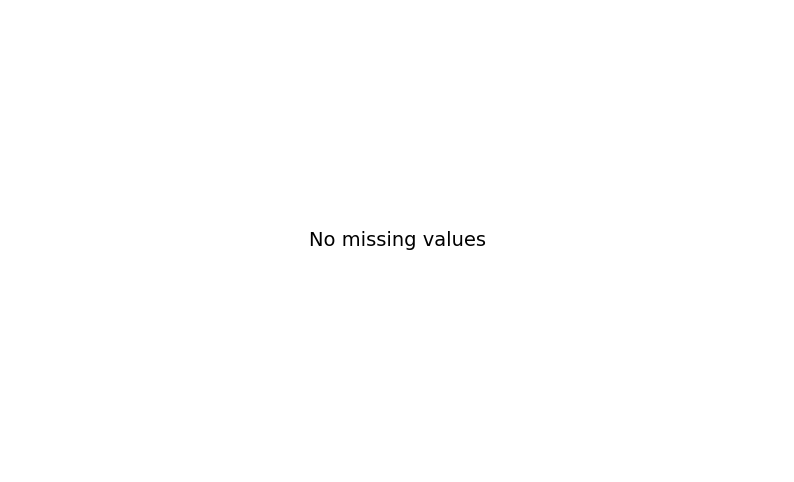

In [67]:
top_missing = missing_report[missing_report["missing_count"] > 0].head(30)

plt.figure(figsize=(10, 6))

if len(top_missing) > 0:
    sns.barplot(
        data=top_missing,
        x="missing_ratio",
        y="column",
        color="steelblue"
    )
    plt.xlabel("Missing ratio")
    plt.ylabel("Feature")
    plt.title("Top Missing Features in Carbon-24 Feature Table")
    plt.grid(True, axis="x")
else:
    plt.text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=14)
    plt.axis("off")

plt.savefig(f"{FIGURES_DIR}/preprocess_missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

**4. Làm sạch cơ bản: duplicate, Carbon-only, energy**

In [68]:
df = feat_df.copy()

print("Before duplicate removal:", df.shape)

if "row_index" in df.columns:
    df = df.drop_duplicates(subset=["row_index"]).copy()
else:
    df = df.drop_duplicates().copy()

print("After duplicate removal:", df.shape)

Before duplicate removal: (10153, 32)
After duplicate removal: (10153, 32)


In [69]:
if "elements" in df.columns:
    print("Elements distribution:")
    display(df["elements"].value_counts().head(20))

Elements distribution:


elements
C    10153
Name: count, dtype: int64

In [70]:
if "elements" in df.columns:
    df = df[df["elements"].astype(str).str.contains("C")].copy()

print("After Carbon filter:", df.shape)

After Carbon filter: (10153, 32)


**5. Kiểm tra năng lượng**

In [71]:
if "energy" in df.columns:
    df["energy"] = pd.to_numeric(df["energy"], errors="coerce")
    
    if "relative_energy" not in df.columns:
        df["relative_energy"] = df["energy"] - df["energy"].min()
    
    df["relative_energy"] = pd.to_numeric(df["relative_energy"], errors="coerce")
    df["relative_energy_meV"] = df["relative_energy"] * 1000
    
    print("Energy min:", df["energy"].min())
    print("Energy max:", df["energy"].max())
    print("Relative energy min:", df["relative_energy"].min())
    print("Relative energy max:", df["relative_energy"].max())
    print("Relative energy max meV:", df["relative_energy_meV"].max())
    
    display(df[["energy", "relative_energy", "relative_energy_meV"]].describe())
else:
    print("No energy column found")

Energy min: -154.556985
Energy max: -154.065601875
Relative energy min: 0.0
Relative energy max: 0.4913831249999987
Relative energy max meV: 491.3831249999987


,energy,relative_energy,relative_energy_meV
count,10153.000000,10153.000000,10153.000000
mean,-154.250522,0.306463,306.462545
std,0.136500,0.136500,136.499577
min,-154.556985,0.000000,0.000000
25%,-154.333489,0.223496,223.496250
50%,-154.217487,0.339498,339.498000
75%,-154.136999,0.419986,419.986333
max,-154.065602,0.491383,491.383125


**6. Tạo feature bổ sung**

In [72]:
# Lattice anisotropy
if all(c in df.columns for c in ["a", "b", "c"]):
    df["lattice_min"] = df[["a", "b", "c"]].min(axis=1)
    df["lattice_max"] = df[["a", "b", "c"]].max(axis=1)
    df["lattice_anisotropy"] = df["lattice_max"] / df["lattice_min"]

# Angle statistics
if all(c in df.columns for c in ["alpha", "beta", "gamma"]):
    df["angle_mean"] = df[["alpha", "beta", "gamma"]].mean(axis=1)
    df["angle_std"] = df[["alpha", "beta", "gamma"]].std(axis=1)

# Volume-density combined check
if "volume_per_atom" in df.columns and "density" in df.columns:
    df["density_x_volume_per_atom"] = df["density"] * df["volume_per_atom"]

print("After feature engineering:", df.shape)
display(df.head())

After feature engineering: (10153, 39)


,formula,elements,num_atoms,a,b,c,alpha,beta,gamma,volume,volume_per_atom,density,b_over_a,c_over_a,angle_deviation,space_group_number,space_group_symbol,crystal_system,mean_bond_length,std_bond_length,min_bond_length,max_bond_length,mean_coordination,std_coordination,min_coordination,max_coordination,row_index,split,source_file,material_id,energy,relative_energy,relative_energy_meV,lattice_min,lattice_max,lattice_anisotropy,angle_mean,angle_std,density_x_volume_per_atom
0,C,C,6,2.48053,5.09056,4.89497,57.97521,59.51109,43.04559,34.994539,5.832423,3.419546,2.052207,1.973357,109.46811,12,C2/m,monoclinic,1.526933,0.023654,1.491934,1.569426,4.0,0.0,4.0,4.0,0,train,huggingface,C-130499-1826-36,-154.311891,0.245094,245.0945,2.48053,5.09056,2.052207,53.510630,9.095467,19.944237
1,C,C,10,2.48986,4.65679,5.94592,90.03290,77.93642,57.67568,56.442646,5.644265,3.533540,1.870302,2.388054,44.42080,12,C2/m,monoclinic,1.529398,0.042382,1.433922,1.592736,4.0,0.0,4.0,4.0,1,train,huggingface,C-13904-4247-31,-154.332183,0.224802,224.8020,2.48986,5.94592,2.388054,75.215000,16.349374,19.944237
2,C,C,10,2.44168,4.79849,5.95909,119.73602,101.56104,75.51457,58.455462,5.845546,3.411869,1.965241,2.440570,55.78249,8,Cm,monoclinic,1.512933,0.027126,1.462408,1.552865,3.8,0.4,3.0,4.0,2,train,huggingface,C-92138-4782-35,-154.178157,0.378828,378.8280,2.44168,5.95909,2.440570,98.937210,22.227180,19.944237
3,C,C,20,2.47518,4.18933,11.18377,100.54005,77.38712,89.87842,111.153317,5.557666,3.588599,1.692535,4.518366,23.27451,1,P1,triclinic,1.531103,0.037765,1.458099,1.624674,4.0,0.0,4.0,4.0,3,train,huggingface,C-192672-505-73,-154.309339,0.247646,247.6460,2.47518,11.18377,4.518366,89.268530,11.588508,19.944237
4,C,C,6,3.39500,4.81978,3.65211,112.26885,128.35152,77.74360,43.348062,7.224677,2.760571,1.419670,1.075732,72.87677,12,C2/m,monoclinic,1.411908,0.021736,1.366340,1.434403,3.0,0.0,3.0,3.0,4,train,huggingface,C-193956-5355-22,-154.141835,0.415150,415.1495,3.39500,4.81978,1.419670,106.121323,25.857967,19.944237


In [73]:
df.to_csv(f"{DATA_DIR}/carbon24_features_engineered.csv", index=False)

**7.  Khai báo feature sets cho KMeans**

In [74]:
geometry_cols = [
    "a", "b", "c",
    "alpha", "beta", "gamma",
    "volume",
    "volume_per_atom",
    "density",
    "num_atoms",
    "b_over_a",
    "c_over_a",
    "angle_deviation",
    "lattice_anisotropy",
    "angle_mean",
    "angle_std",
    "space_group_number",
    "mean_bond_length",
    "std_bond_length",
    "min_bond_length",
    "max_bond_length",
    "mean_coordination",
    "std_coordination",
    "min_coordination",
    "max_coordination",
]

geometry_cols = [c for c in geometry_cols if c in df.columns]

geometry_energy_cols = geometry_cols.copy()

if "relative_energy" in df.columns:
    geometry_energy_cols.append("relative_energy")

feature_sets = {
    "geometry_only": geometry_cols,
    "geometry_energy": geometry_energy_cols,
}

for name, cols in feature_sets.items():
    print("=" * 80)
    print(name)
    print("n_features:", len(cols))
    print(cols)

geometry_only
n_features: 25
['a', 'b', 'c', 'alpha', 'beta', 'gamma', 'volume', 'volume_per_atom', 'density', 'num_atoms', 'b_over_a', 'c_over_a', 'angle_deviation', 'lattice_anisotropy', 'angle_mean', 'angle_std', 'space_group_number', 'mean_bond_length', 'std_bond_length', 'min_bond_length', 'max_bond_length', 'mean_coordination', 'std_coordination', 'min_coordination', 'max_coordination']
geometry_energy
n_features: 26
['a', 'b', 'c', 'alpha', 'beta', 'gamma', 'volume', 'volume_per_atom', 'density', 'num_atoms', 'b_over_a', 'c_over_a', 'angle_deviation', 'lattice_anisotropy', 'angle_mean', 'angle_std', 'space_group_number', 'mean_bond_length', 'std_bond_length', 'min_bond_length', 'max_bond_length', 'mean_coordination', 'std_coordination', 'min_coordination', 'max_coordination', 'relative_energy']


In [75]:
with open(f"{TABLES_DIR}/feature_sets.json", "w", encoding="utf-8") as f:
    json.dump(feature_sets, f, indent=2, ensure_ascii=False)

**8. Hàm tiền xử lý hoàn chỉnh**

In [78]:
def winsorize_dataframe(X_df, lower_q=0.01, upper_q=0.99):
    """
    Cắt outlier theo percentile.
    Không xóa dòng, chỉ giới hạn giá trị cực đoan.
    """
    X_w = X_df.copy()
    lower = X_w.quantile(lower_q)
    upper = X_w.quantile(upper_q)
    X_w = X_w.clip(lower=lower, upper=upper, axis=1)
    return X_w, lower, upper


def remove_highly_correlated_features(X_df, threshold=0.95, protected_cols=None):
    """
    Loại feature tương quan cao.
    protected_cols là các feature muốn giữ lại, ví dụ relative_energy.
    """
    if protected_cols is None:
        protected_cols = []
    
    corr = X_df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    
    to_drop = []
    
    for col in upper.columns:
        if col in protected_cols:
            continue
        
        high_corr = upper[col][upper[col] > threshold]
        
        if len(high_corr) > 0:
            to_drop.append(col)
    
    to_drop = sorted(set(to_drop))
    kept_cols = [c for c in X_df.columns if c not in to_drop]
    
    return kept_cols, to_drop, corr


def preprocess_for_kmeans(
    df,
    feature_cols,
    feature_set_name="geometry_energy",
    missing_col_threshold=0.3,
    corr_threshold=0.95,
    winsorize=True,
    scaler_type="standard",
    protected_cols=None
):
    if protected_cols is None:
        protected_cols = []
    
    # 1. Chỉ lấy feature tồn tại
    feature_cols = [c for c in feature_cols if c in df.columns]
    
    if len(feature_cols) == 0:
        raise ValueError("Không có feature nào tồn tại trong dataframe.")
    
    X_raw = df[feature_cols].copy()
    
    # 2. Ép numeric
    for col in X_raw.columns:
        X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")
    
    # 3. Bỏ dòng toàn NaN
    valid_mask = ~X_raw.isna().all(axis=1)
    X_raw = X_raw.loc[valid_mask].copy()
    df_valid = df.loc[X_raw.index].copy()
    
    # 4. Missing filtering
    missing_ratio = X_raw.isna().mean().sort_values(ascending=False)
    
    keep_cols = missing_ratio[missing_ratio <= missing_col_threshold].index.tolist()
    dropped_missing_cols = [c for c in X_raw.columns if c not in keep_cols]
    
    X_raw = X_raw[keep_cols].copy()
    
    if X_raw.shape[1] == 0:
        raise ValueError("Tất cả feature bị loại do missing_col_threshold quá thấp.")
    
    # 5. Median imputation
    imputer = SimpleImputer(strategy="median")
    X_imp_arr = imputer.fit_transform(X_raw)
    
    X_imp = pd.DataFrame(
        X_imp_arr,
        columns=X_raw.columns,
        index=X_raw.index
    )
    
    # 6. Variance filtering
    vt = VarianceThreshold(threshold=0.0)
    X_vt_arr = vt.fit_transform(X_imp)
    vt_cols = X_imp.columns[vt.get_support()].tolist()
    
    dropped_constant_cols = [c for c in X_imp.columns if c not in vt_cols]
    
    X_vt = pd.DataFrame(
        X_vt_arr,
        columns=vt_cols,
        index=X_imp.index
    )
    
    # 7. Winsorization
    if winsorize:
        X_out, lower_bounds, upper_bounds = winsorize_dataframe(
            X_vt,
            lower_q=0.01,
            upper_q=0.99
        )
    else:
        X_out = X_vt.copy()
        lower_bounds = None
        upper_bounds = None
    
    # 8. Correlation filtering
    kept_corr_cols, dropped_corr_cols, corr_matrix = remove_highly_correlated_features(
        X_out,
        threshold=corr_threshold,
        protected_cols=protected_cols
    )
    
    X_corr = X_out[kept_corr_cols].copy()
    
    if X_corr.shape[1] == 0:
        raise ValueError("Tất cả feature bị loại sau correlation filtering.")
    
    # 9. Scaling
    if scaler_type == "standard":
        scaler = StandardScaler()
    elif scaler_type == "robust":
        scaler = RobustScaler()
    else:
        raise ValueError("scaler_type phải là 'standard' hoặc 'robust'")
    
    X_scaled_arr = scaler.fit_transform(X_corr)
    
    X_scaled_df = pd.DataFrame(
        X_scaled_arr,
        columns=X_corr.columns,
        index=X_corr.index
    )
    
    report = {
        "feature_set_name": feature_set_name,
        "n_rows_original": len(df),
        "n_rows_valid": len(df_valid),
        "n_features_input": len(feature_cols),
        "n_features_after_missing_filter": len(keep_cols),
        "n_features_after_variance_filter": len(vt_cols),
        "n_features_final": X_scaled_df.shape[1],
        "scaler_type": scaler_type,
        "winsorize": winsorize,
        "missing_col_threshold": missing_col_threshold,
        "corr_threshold": corr_threshold,
        "dropped_missing_cols": dropped_missing_cols,
        "dropped_constant_cols": dropped_constant_cols,
        "dropped_corr_cols": dropped_corr_cols,
        "final_feature_cols": X_scaled_df.columns.tolist(),
    }
    
    objects = {
        "imputer": imputer,
        "scaler": scaler,
        "lower_bounds": lower_bounds,
        "upper_bounds": upper_bounds,
        "corr_matrix_before_filter": corr_matrix,
        "missing_ratio": missing_ratio,
        "X_raw": X_raw,
        "X_imputed": X_imp,
        "X_after_variance": X_vt,
        "X_after_winsor": X_out,
        "X_after_corr": X_corr,
        "X_scaled_df": X_scaled_df,
    }
    
    return X_scaled_arr, X_scaled_df, df_valid, report, objects

**9. Hàm plot cho bước tiền xử lý**

In [79]:
def plot_correlation_heatmaps(prep_objects, feature_set_name, figures_dir):
    X_before = prep_objects["X_after_winsor"]
    X_after = prep_objects["X_after_corr"]
    
    corr_before = X_before.corr()
    corr_after = X_after.corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        corr_before,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.2,
        cbar_kws={"shrink": 0.8}
    )
    plt.title(f"Correlation Heatmap Before Filtering - {feature_set_name}")
    plt.tight_layout()
    plt.savefig(
        f"{figures_dir}/corr_heatmap_before_{feature_set_name}.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_after,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.2,
        cbar_kws={"shrink": 0.8}
    )
    plt.title(f"Correlation Heatmap After Filtering - {feature_set_name}")
    plt.tight_layout()
    plt.savefig(
        f"{figures_dir}/corr_heatmap_after_{feature_set_name}.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()


def plot_feature_distributions(prep_objects, feature_set_name, figures_dir):
    important_features = [
        "volume_per_atom",
        "density",
        "mean_bond_length",
        "mean_coordination",
        "relative_energy",
        "lattice_anisotropy",
        "angle_std",
    ]
    
    available_features = [
        c for c in important_features
        if c in prep_objects["X_after_variance"].columns
        and c in prep_objects["X_after_winsor"].columns
    ]
    
    print("Distribution features:", available_features)
    
    for col in available_features:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        sns.histplot(
            prep_objects["X_after_variance"][col],
            bins=40,
            kde=True,
            ax=axes[0],
            color="steelblue"
        )
        axes[0].set_title(f"Before Winsorization: {col}")
        axes[0].grid(True)
        
        sns.histplot(
            prep_objects["X_after_winsor"][col],
            bins=40,
            kde=True,
            ax=axes[1],
            color="darkorange"
        )
        axes[1].set_title(f"After Winsorization: {col}")
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.savefig(
            f"{figures_dir}/distribution_{feature_set_name}_{col}.png",
            dpi=200,
            bbox_inches="tight"
        )
        plt.show()


def plot_pca_before_clustering(X_scaled, df_valid, feature_set_name, figures_dir):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    pca_df = df_valid.copy()
    pca_df["PC1"] = X_pca[:, 0]
    pca_df["PC2"] = X_pca[:, 1]
    
    print(f"{feature_set_name} PCA explained variance:", pca.explained_variance_ratio_)
    print(f"{feature_set_name} PCA total:", pca.explained_variance_ratio_.sum())
    
    # PCA colored by energy
    if "relative_energy" in pca_df.columns:
        plt.figure(figsize=(8, 6))
        sc = plt.scatter(
            pca_df["PC1"],
            pca_df["PC2"],
            c=pca_df["relative_energy"],
            cmap="viridis",
            s=35,
            alpha=0.8
        )
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(f"PCA Before Clustering Colored by Relative Energy - {feature_set_name}")
        plt.colorbar(sc, label="Relative energy")
        plt.grid(True)
        plt.savefig(
            f"{figures_dir}/pca_before_clustering_energy_{feature_set_name}.png",
            dpi=200,
            bbox_inches="tight"
        )
        plt.show()
    
    # PCA colored by crystal system
    if "crystal_system" in pca_df.columns:
        plt.figure(figsize=(9, 6))
        sns.scatterplot(
            data=pca_df,
            x="PC1",
            y="PC2",
            hue="crystal_system",
            s=35,
            alpha=0.8
        )
        plt.title(f"PCA Before Clustering Colored by Crystal System - {feature_set_name}")
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.savefig(
            f"{figures_dir}/pca_before_clustering_crystal_system_{feature_set_name}.png",
            dpi=200,
            bbox_inches="tight"
        )
        plt.show()
    
    return pca, pca_df

**10. Chạy tiền xử lý cho 2 feature sets**

Preprocessing: geometry_only
X_scaled shape: (10153, 21)
Final features: ['a', 'b', 'c', 'alpha', 'beta', 'gamma', 'volume', 'volume_per_atom', 'b_over_a', 'c_over_a', 'angle_deviation', 'angle_mean', 'angle_std', 'space_group_number', 'mean_bond_length', 'std_bond_length', 'min_bond_length', 'max_bond_length', 'std_coordination', 'min_coordination', 'max_coordination']
Dropped correlated: ['density', 'lattice_anisotropy', 'mean_coordination', 'num_atoms']


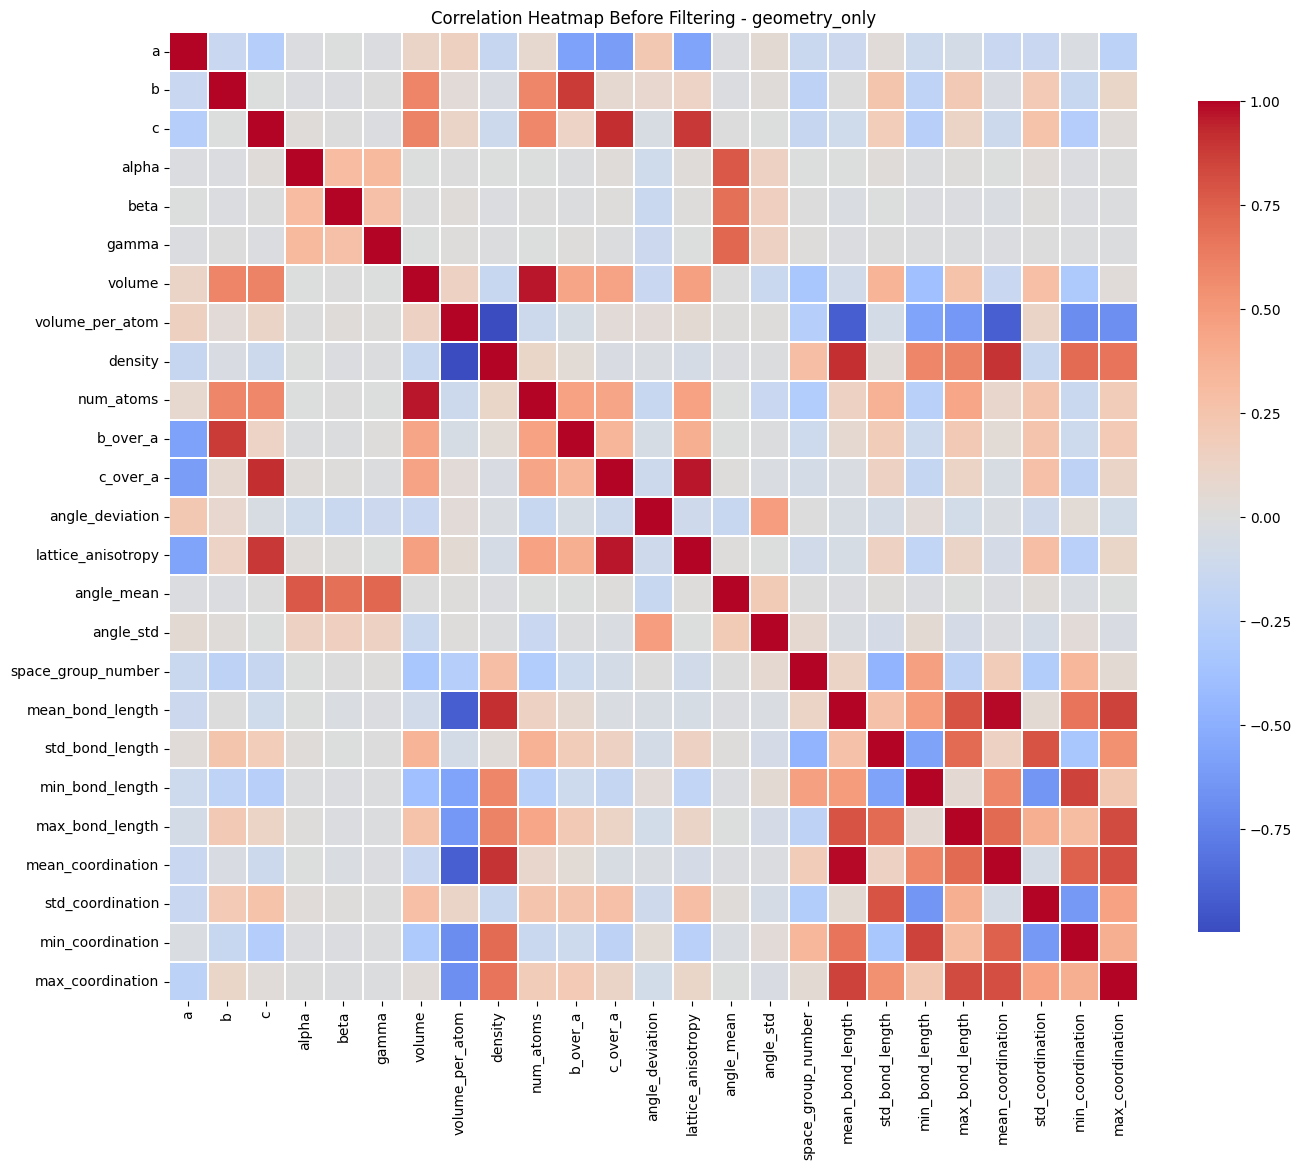

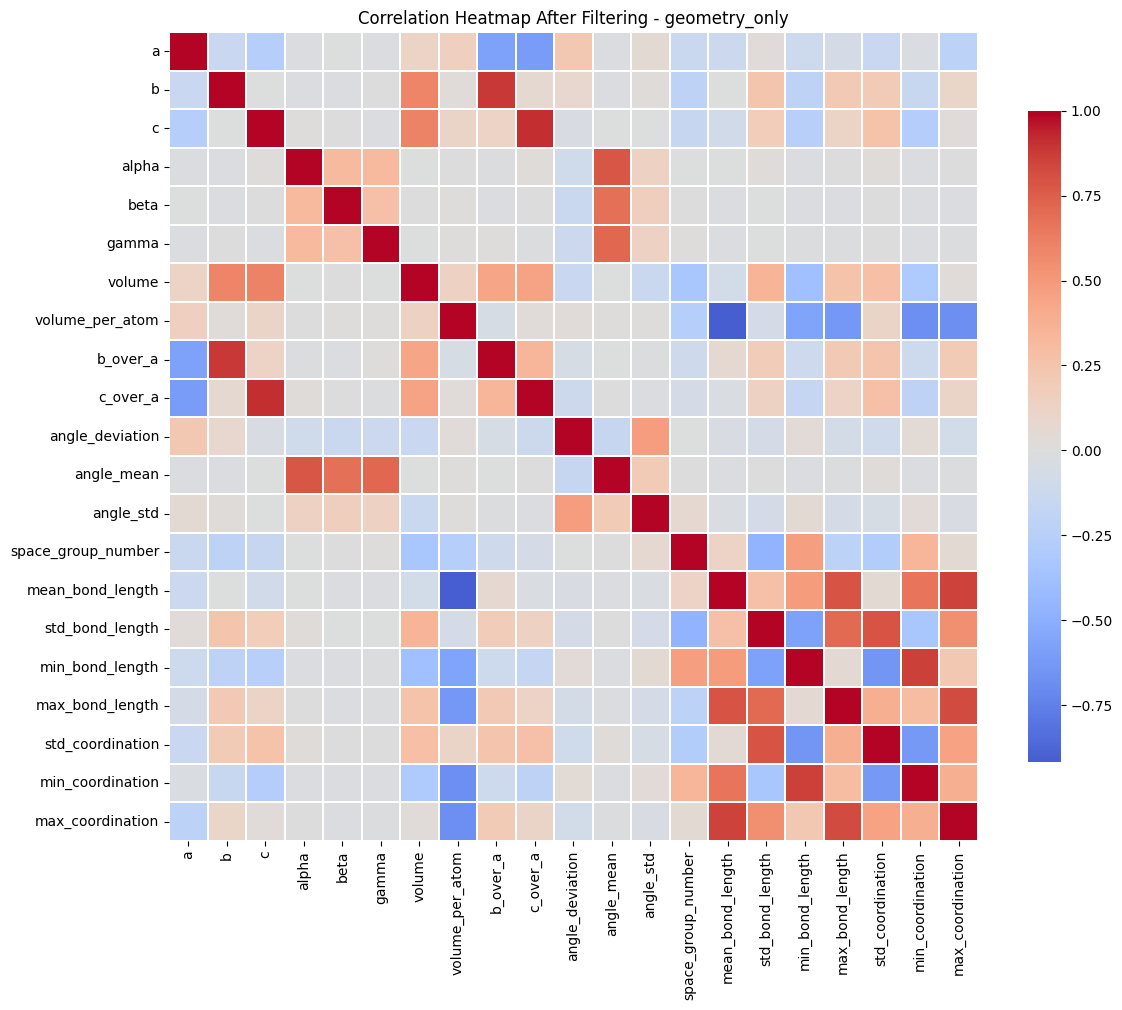

Distribution features: ['volume_per_atom', 'density', 'mean_bond_length', 'mean_coordination', 'lattice_anisotropy', 'angle_std']


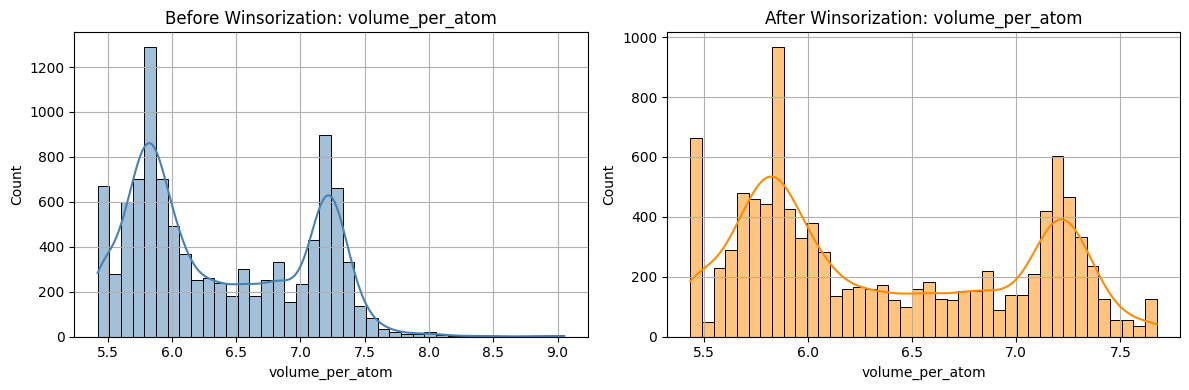

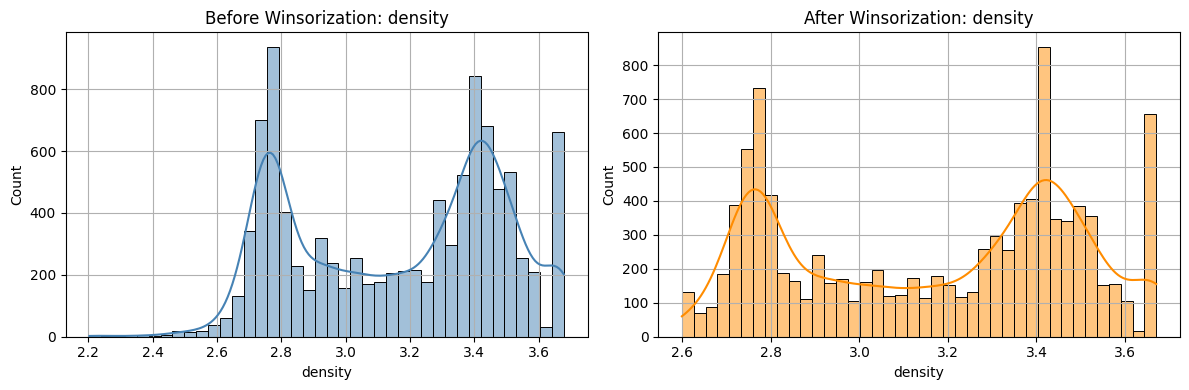

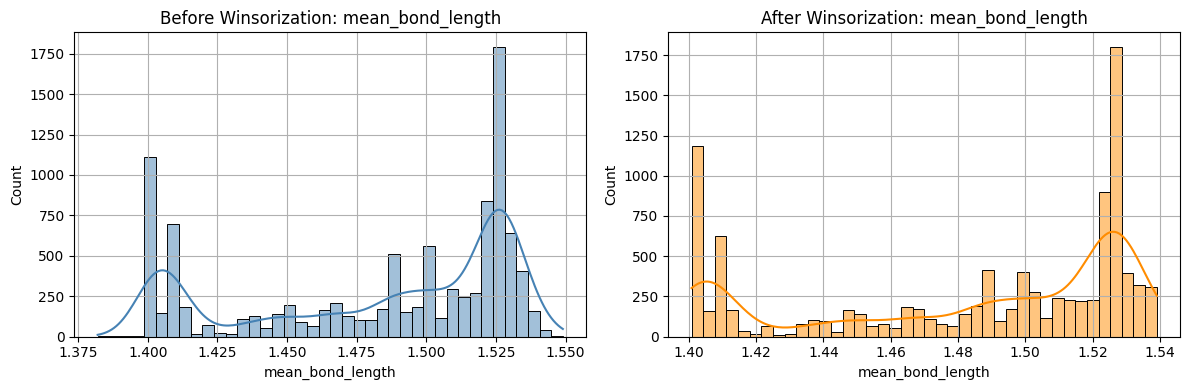

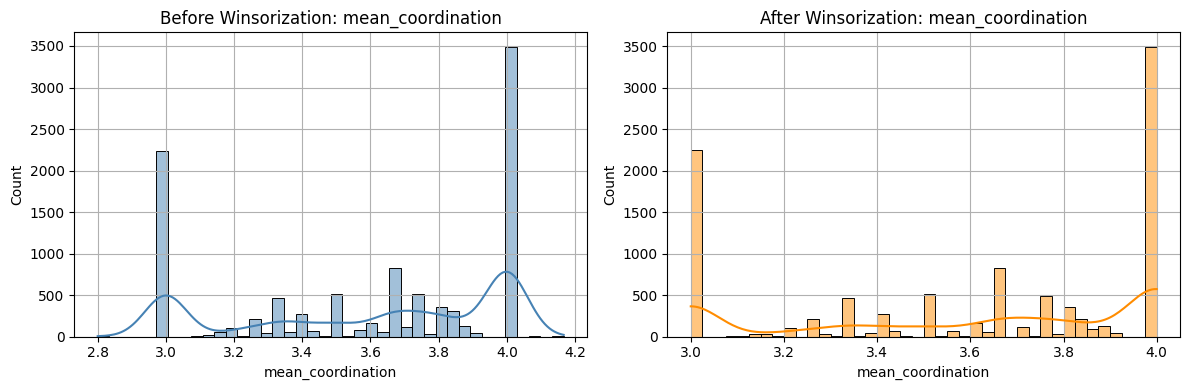

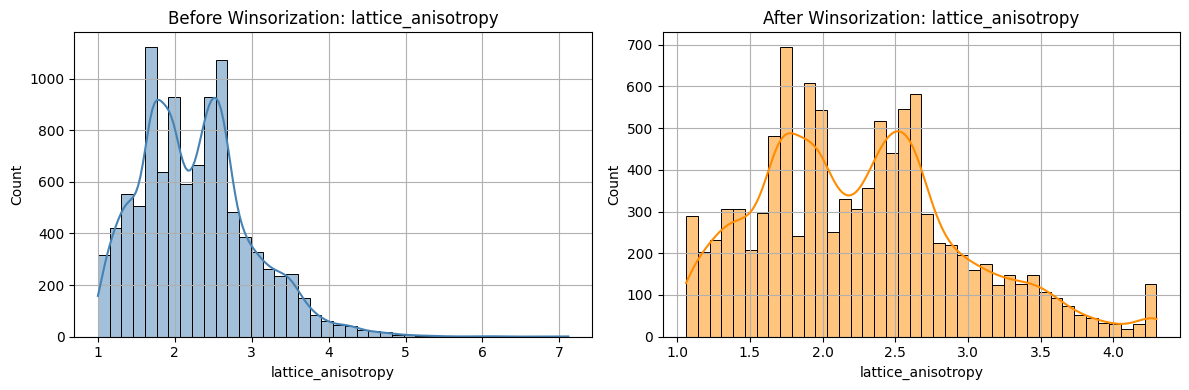

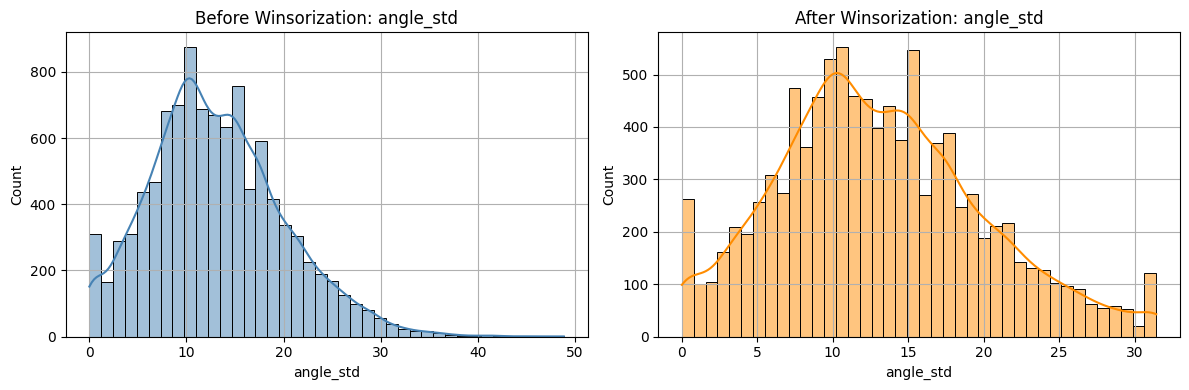

geometry_only PCA explained variance: [0.21073344 0.19916445]
geometry_only PCA total: 0.409897888391502


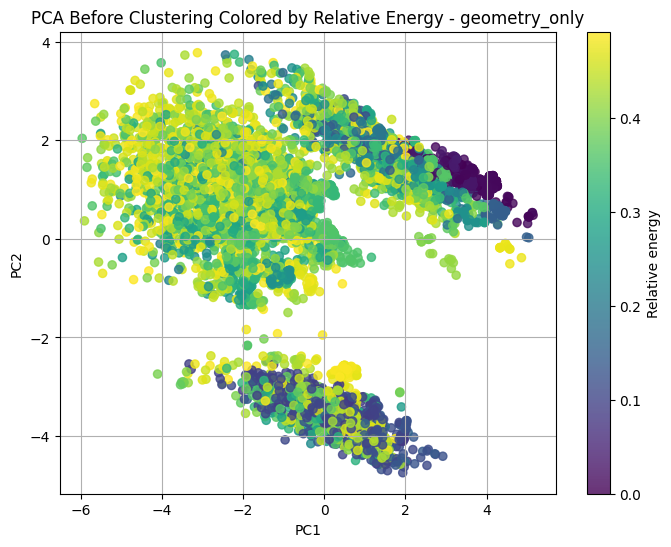

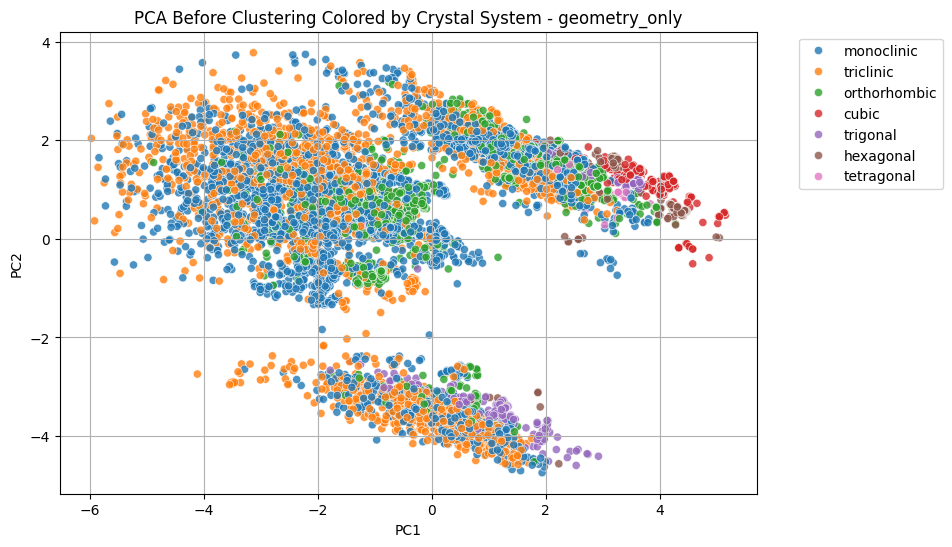

Preprocessing: geometry_energy
X_scaled shape: (10153, 22)
Final features: ['a', 'b', 'c', 'alpha', 'beta', 'gamma', 'volume', 'volume_per_atom', 'b_over_a', 'c_over_a', 'angle_deviation', 'angle_mean', 'angle_std', 'space_group_number', 'mean_bond_length', 'std_bond_length', 'min_bond_length', 'max_bond_length', 'std_coordination', 'min_coordination', 'max_coordination', 'relative_energy']
Dropped correlated: ['density', 'lattice_anisotropy', 'mean_coordination', 'num_atoms']


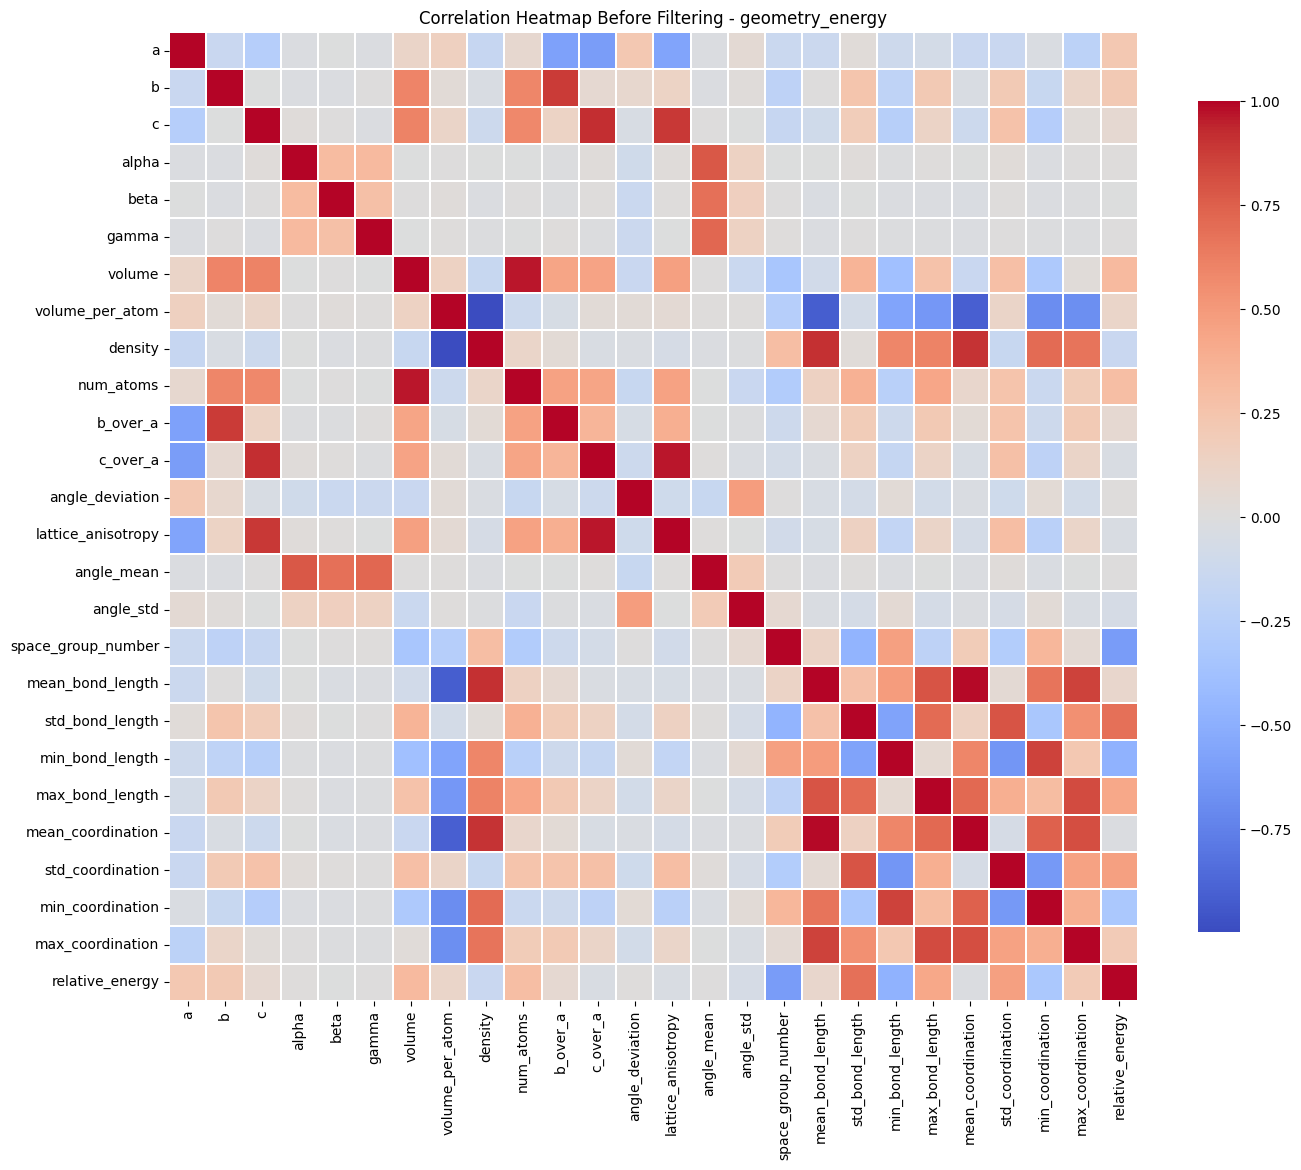

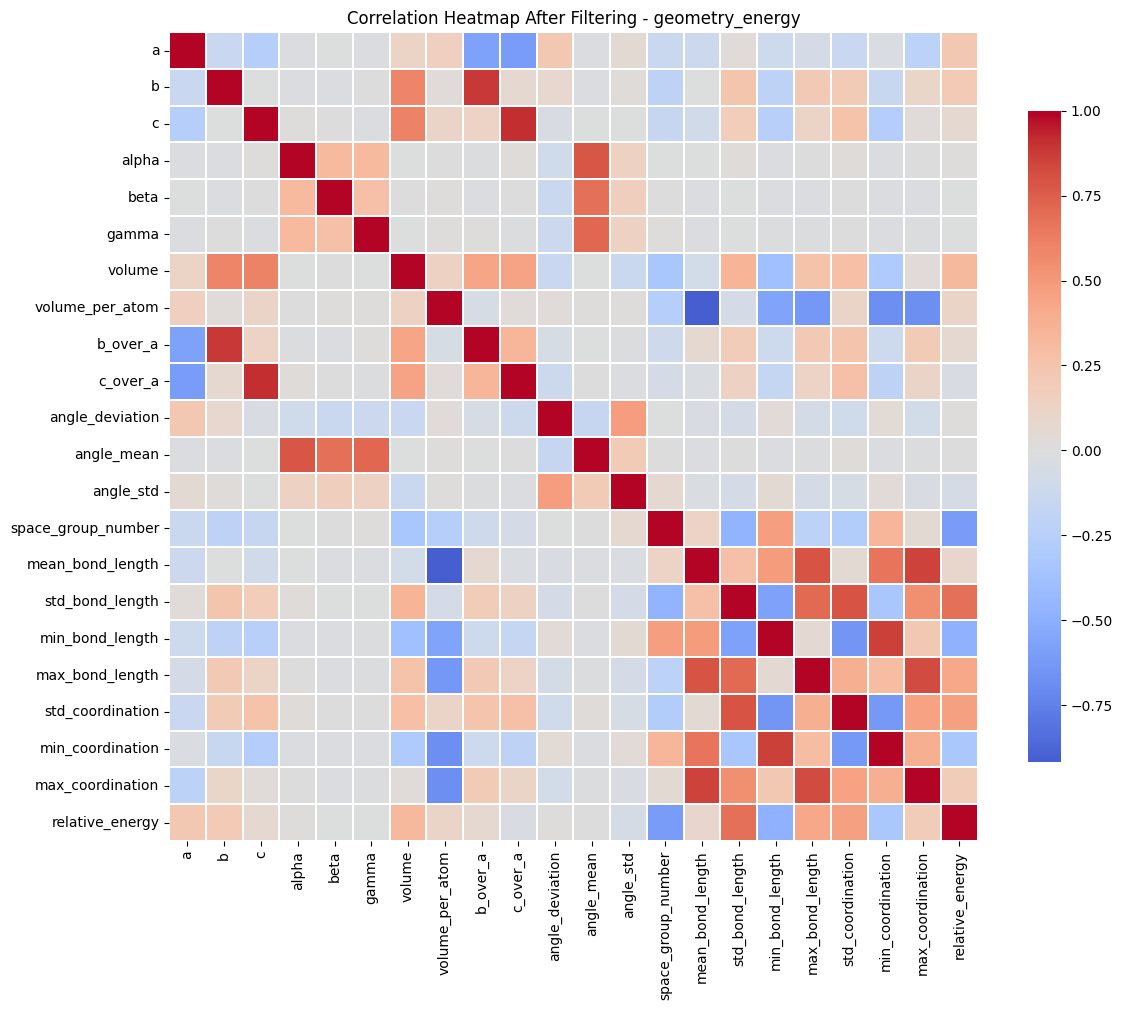

Distribution features: ['volume_per_atom', 'density', 'mean_bond_length', 'mean_coordination', 'relative_energy', 'lattice_anisotropy', 'angle_std']


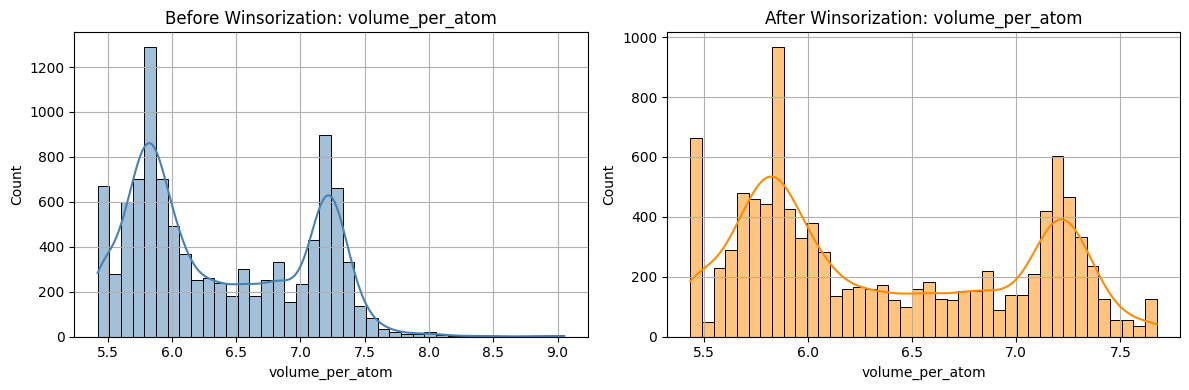

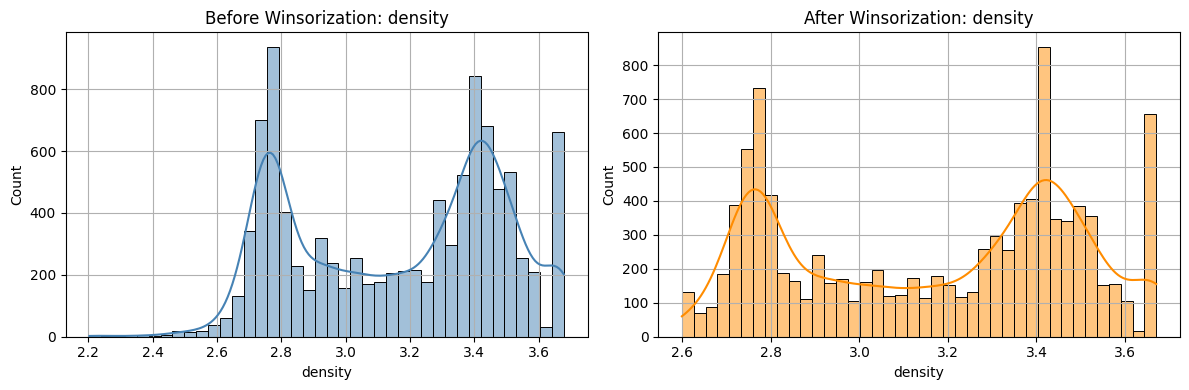

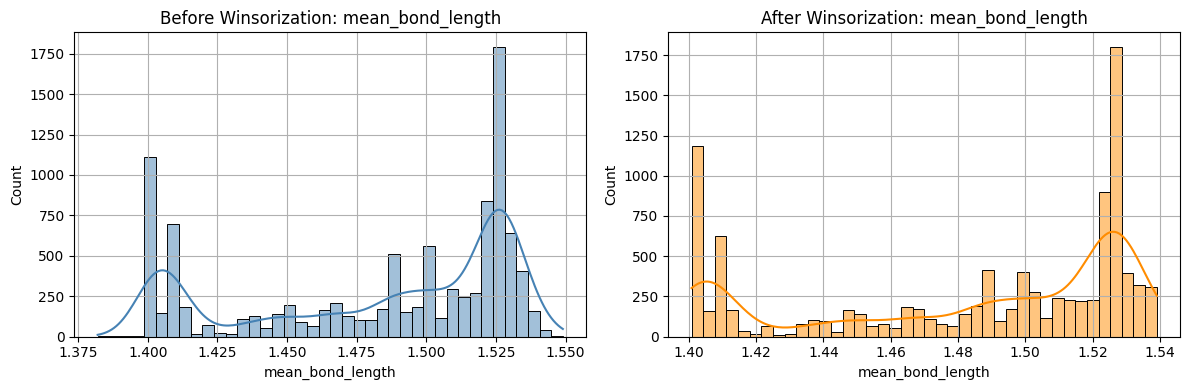

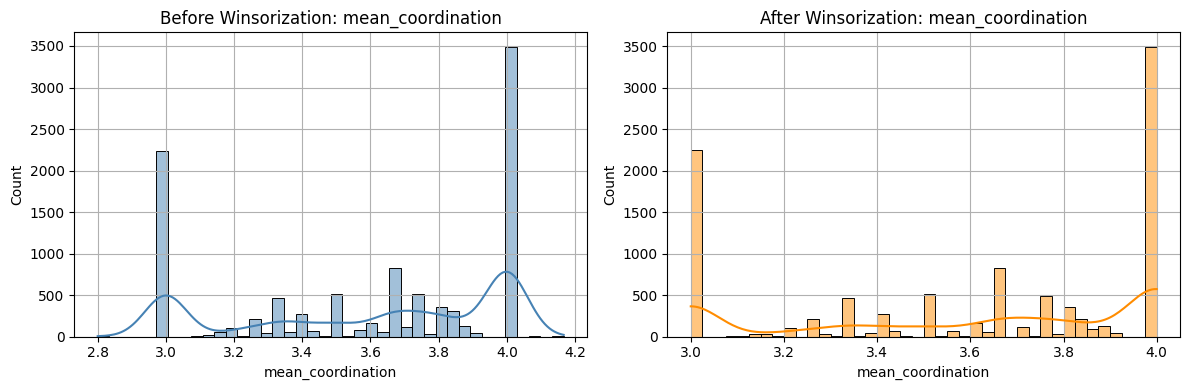

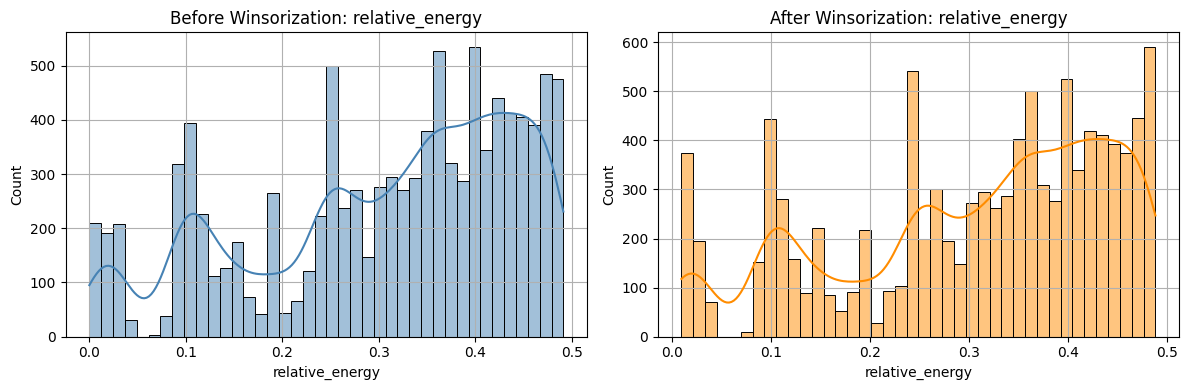

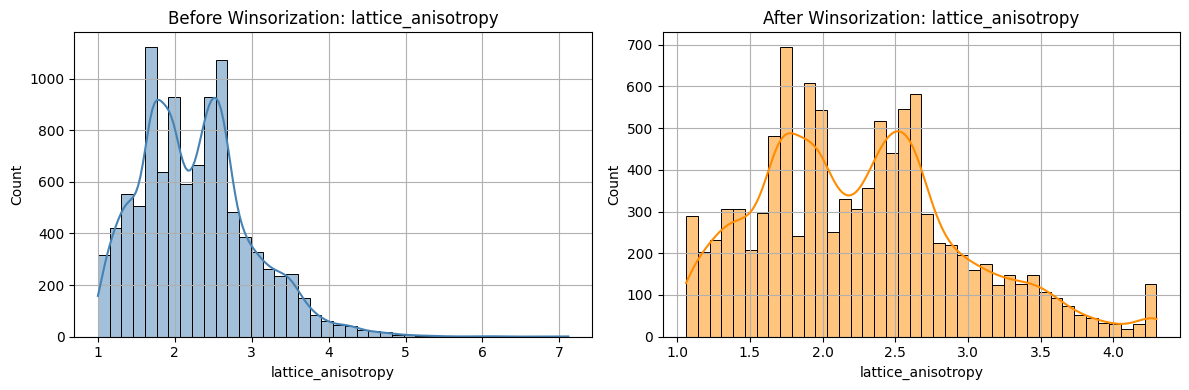

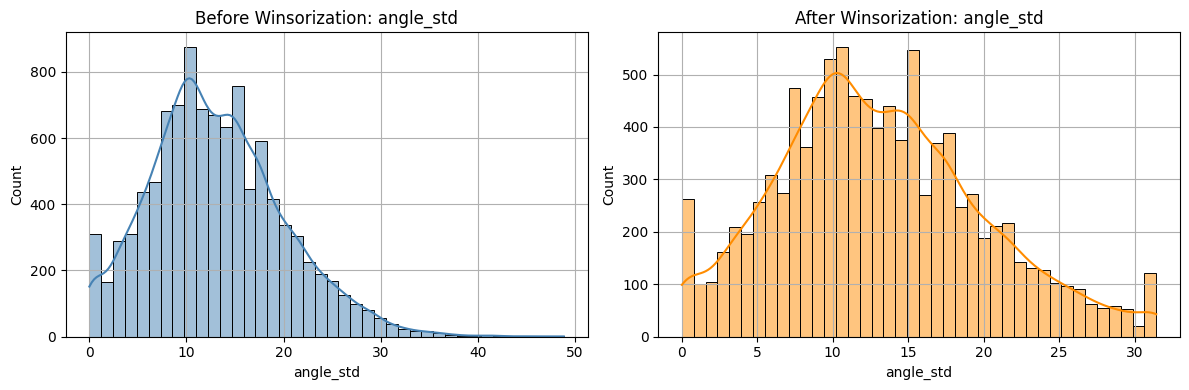

geometry_energy PCA explained variance: [0.21635217 0.19067154]
geometry_energy PCA total: 0.407023710905709


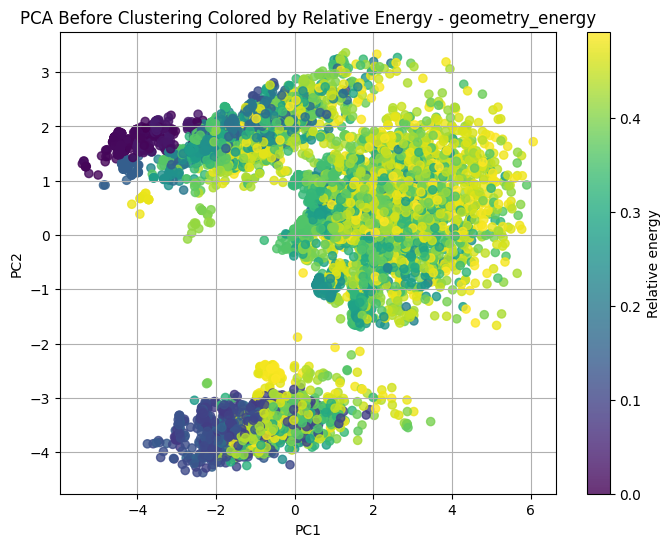

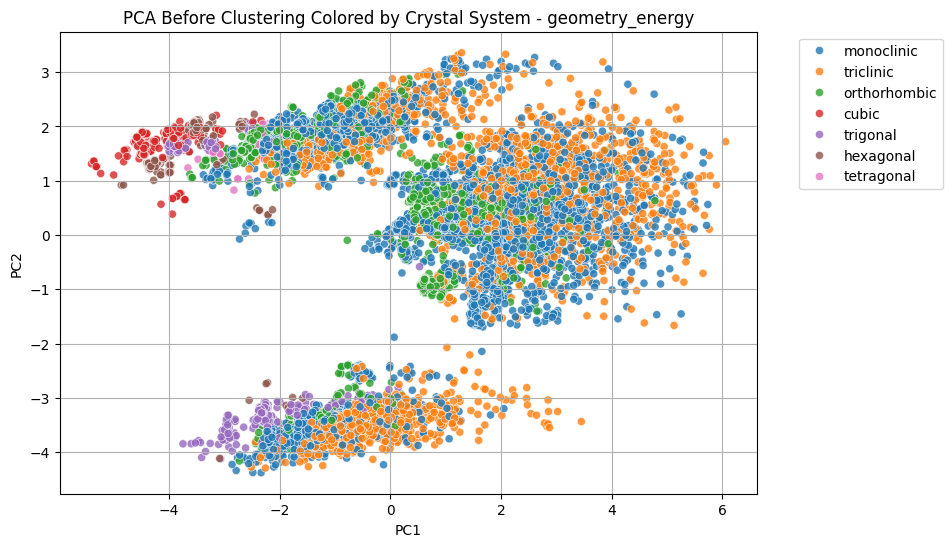

In [80]:
preprocessed_data = {}

for feature_set_name, cols in feature_sets.items():
    print("=" * 100)
    print("Preprocessing:", feature_set_name)
    
    protected_cols = []
    if feature_set_name == "geometry_energy" and "relative_energy" in cols:
        protected_cols = ["relative_energy"]
    
    X_scaled, X_scaled_df, df_valid, prep_report, prep_objects = preprocess_for_kmeans(
        df=df,
        feature_cols=cols,
        feature_set_name=feature_set_name,
        missing_col_threshold=0.3,
        corr_threshold=0.95,
        winsorize=True,
        scaler_type="standard",
        protected_cols=protected_cols
    )
    
    preprocessed_data[feature_set_name] = {
        "X_scaled": X_scaled,
        "X_scaled_df": X_scaled_df,
        "df_valid": df_valid,
        "prep_report": prep_report,
        "prep_objects": prep_objects,
    }
    
    print("X_scaled shape:", X_scaled.shape)
    print("Final features:", prep_report["final_feature_cols"])
    print("Dropped correlated:", prep_report["dropped_corr_cols"])
    
    # Save report
    with open(f"{TABLES_DIR}/preprocessing_report_{feature_set_name}.json", "w", encoding="utf-8") as f:
        json.dump(prep_report, f, indent=2, ensure_ascii=False)
    
    # Save final feature list
    pd.DataFrame({
        "final_feature_cols": prep_report["final_feature_cols"]
    }).to_csv(f"{TABLES_DIR}/final_features_{feature_set_name}.csv", index=False)
    
    # Save dropped correlated features
    pd.DataFrame({
        "dropped_corr_cols": prep_report["dropped_corr_cols"]
    }).to_csv(f"{TABLES_DIR}/dropped_corr_features_{feature_set_name}.csv", index=False)
    
    # Save X_scaled
    X_scaled_df.to_csv(f"{PREPROCESS_DIR}/X_scaled_{feature_set_name}.csv", index=False)
    
    # Save correlation matrices
    prep_objects["X_after_winsor"].corr().to_csv(
        f"{TABLES_DIR}/corr_before_filter_{feature_set_name}.csv"
    )
    prep_objects["X_after_corr"].corr().to_csv(
        f"{TABLES_DIR}/corr_after_filter_{feature_set_name}.csv"
    )
    
    # Plot preprocessing
    plot_correlation_heatmaps(prep_objects, feature_set_name, FIGURES_DIR)
    plot_feature_distributions(prep_objects, feature_set_name, FIGURES_DIR)
    pca, pca_df = plot_pca_before_clustering(X_scaled, df_valid, feature_set_name, FIGURES_DIR)
    
    preprocessed_data[feature_set_name]["pca"] = pca
    preprocessed_data[feature_set_name]["pca_df"] = pca_df

**11. Hàm đánh giá KMeans**

In [81]:
def evaluate_clustering_for_kmeans(X, labels, sample_size=5000, random_state=42):
    labels = np.asarray(labels)
    
    n_clusters = len(set(labels))
    
    if n_clusters < 2:
        return {
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }
    
    n_samples = X.shape[0]
    
    if n_samples > sample_size:
        sil = silhouette_score(
            X,
            labels,
            sample_size=sample_size,
            random_state=random_state
        )
    else:
        sil = silhouette_score(X, labels)
    
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    return {
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
    }

**Chạy KMeans grid search cho cả 2 feature sets**

In [82]:
from sklearn.cluster import KMeans

all_kmeans_results = []
all_kmeans_models = {}

K_RANGE = range(2, 11)

for feature_set_name, data_obj in preprocessed_data.items():
    print("=" * 100)
    print("Running KMeans for:", feature_set_name)
    
    X_scaled = data_obj["X_scaled"]
    
    for k in K_RANGE:
        print(f"Feature set = {feature_set_name}, k = {k}")
        
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )
        
        labels = kmeans.fit_predict(X_scaled)
        
        metrics = evaluate_clustering_for_kmeans(
            X_scaled,
            labels,
            sample_size=5000,
            random_state=42
        )
        
        result = {
            "method": "KMeans",
            "feature_set": feature_set_name,
            "k": k,
            "n_samples": X_scaled.shape[0],
            "n_features": X_scaled.shape[1],
            "inertia": kmeans.inertia_,
            **metrics,
        }
        
        all_kmeans_results.append(result)
        all_kmeans_models[(feature_set_name, k)] = {
            "model": kmeans,
            "labels": labels,
        }

kmeans_results_df = pd.DataFrame(all_kmeans_results)

display(kmeans_results_df)

kmeans_results_df.to_csv(f"{RESULTS_DIR}/kmeans_results_all.csv", index=False)

Running KMeans for: geometry_only
Feature set = geometry_only, k = 2
Feature set = geometry_only, k = 3
Feature set = geometry_only, k = 4
Feature set = geometry_only, k = 5
Feature set = geometry_only, k = 6
Feature set = geometry_only, k = 7
Feature set = geometry_only, k = 8
Feature set = geometry_only, k = 9
Feature set = geometry_only, k = 10
Running KMeans for: geometry_energy
Feature set = geometry_energy, k = 2
Feature set = geometry_energy, k = 3
Feature set = geometry_energy, k = 4
Feature set = geometry_energy, k = 5
Feature set = geometry_energy, k = 6
Feature set = geometry_energy, k = 7
Feature set = geometry_energy, k = 8
Feature set = geometry_energy, k = 9
Feature set = geometry_energy, k = 10


,method,feature_set,k,n_samples,n_features,inertia,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,geometry_only,2,10153,21,174988.916933,0.182831,1.909765,2217.355670
1,KMeans,geometry_only,3,10153,21,139794.523536,0.243012,1.606407,2665.331650
2,KMeans,geometry_only,4,10153,21,128443.801391,0.204406,1.794290,2232.686213
3,KMeans,geometry_only,5,10153,21,120784.152670,0.195017,1.828536,1941.414685
4,KMeans,geometry_only,6,10153,21,114829.693840,0.191621,1.722772,1738.742146
5,KMeans,geometry_only,7,10153,21,109535.745591,0.173654,1.865861,1600.559186
6,KMeans,geometry_only,8,10153,21,104484.140311,0.159710,1.977445,1508.163656
7,KMeans,geometry_only,9,10153,21,100575.995501,0.162603,1.869390,1420.058257
8,KMeans,geometry_only,10,10153,21,97145.858150,0.159435,1.846420,1346.508811
9,KMeans,geometry_energy,2,10153,22,184077.635447,0.179813,1.936799,2166.565143


**2. Vẽ Elbow plot**

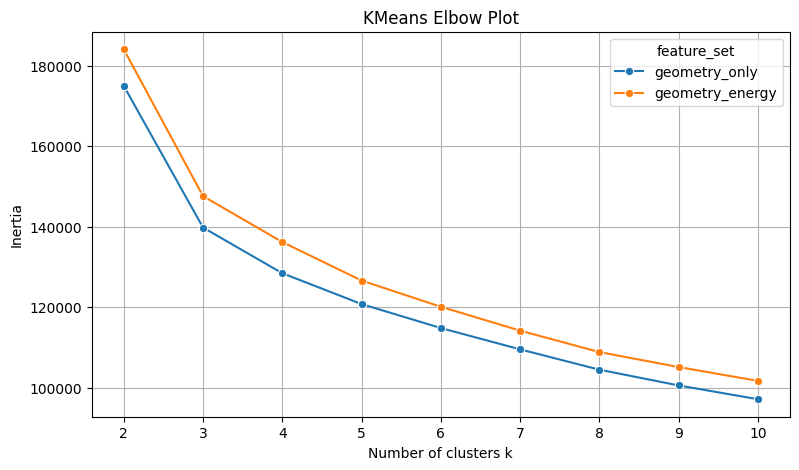

In [83]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=kmeans_results_df,
    x="k",
    y="inertia",
    hue="feature_set",
    marker="o"
)

plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("KMeans Elbow Plot")
plt.grid(True)

plt.savefig(f"{FIGURES_DIR}/kmeans_elbow_plot.png", dpi=200, bbox_inches="tight")
plt.show()

**3. Vẽ Silhouette theo k**

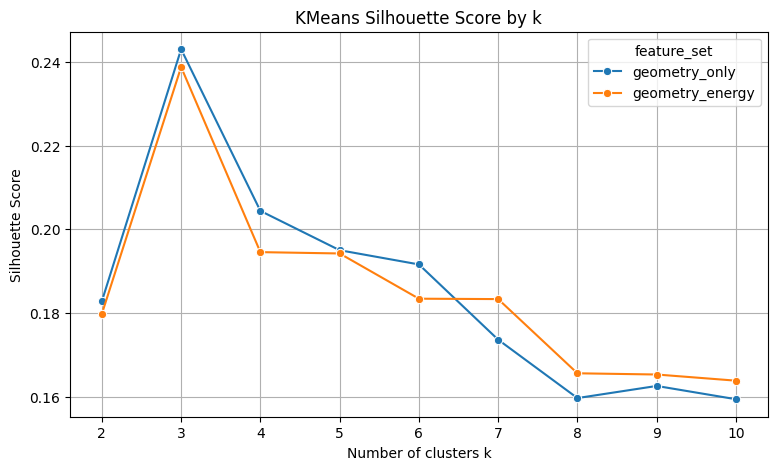

In [85]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=kmeans_results_df,
    x="k",
    y="silhouette",
    hue="feature_set",
    marker="o"
)

plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("KMeans Silhouette Score by k")
plt.grid(True)

plt.savefig(f"{FIGURES_DIR}/kmeans_silhouette_by_k.png", dpi=200, bbox_inches="tight")
plt.show()

**4. Vẽ Davies-Bouldin theo k**

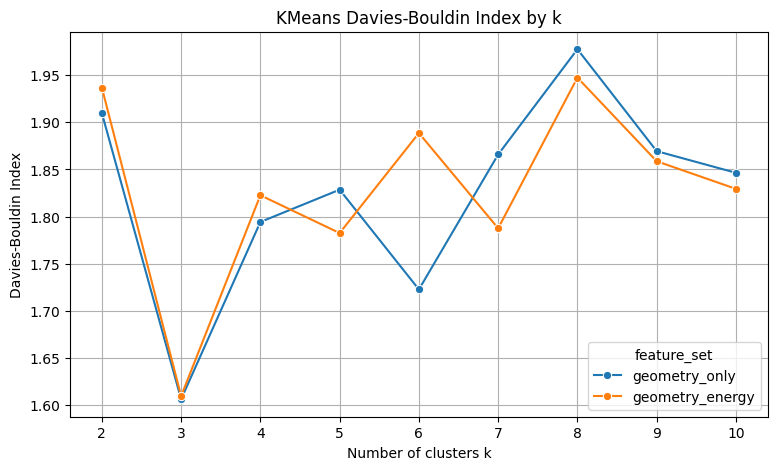

In [86]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=kmeans_results_df,
    x="k",
    y="davies_bouldin",
    hue="feature_set",
    marker="o"
)

plt.xlabel("Number of clusters k")
plt.ylabel("Davies-Bouldin Index")
plt.title("KMeans Davies-Bouldin Index by k")
plt.grid(True)

plt.savefig(f"{FIGURES_DIR}/kmeans_davies_bouldin_by_k.png", dpi=200, bbox_inches="tight")
plt.show()

**5. Vẽ Calinski-Harabasz theo k**

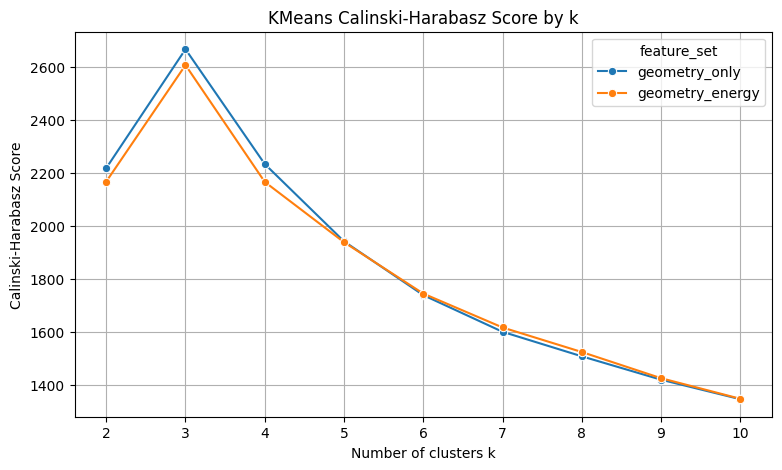

In [88]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=kmeans_results_df,
    x="k",
    y="calinski_harabasz",
    hue="feature_set",
    marker="o"
)

plt.xlabel("Number of clusters k")
plt.ylabel("Calinski-Harabasz Score")
plt.title("KMeans Calinski-Harabasz Score by k")
plt.grid(True)

plt.savefig(f"{FIGURES_DIR}/kmeans_calinski_harabasz_by_k.png", dpi=200, bbox_inches="tight")
plt.show()

**6. Chọn cấu hình KMeans tốt nhất**

In [89]:
best_by_silhouette = (
    kmeans_results_df
    .dropna(subset=["silhouette"])
    .sort_values("silhouette", ascending=False)
    .head(10)
)

display(best_by_silhouette)

best_by_silhouette.to_csv(f"{RESULTS_DIR}/kmeans_best_by_silhouette.csv", index=False)

,method,feature_set,k,n_samples,n_features,inertia,silhouette,davies_bouldin,calinski_harabasz
1,KMeans,geometry_only,3,10153,21,139794.523536,0.243012,1.606407,2665.331650
10,KMeans,geometry_energy,3,10153,22,147590.051364,0.238750,1.609664,2605.615594
2,KMeans,geometry_only,4,10153,21,128443.801391,0.204406,1.794290,2232.686213
3,KMeans,geometry_only,5,10153,21,120784.152670,0.195017,1.828536,1941.414685
11,KMeans,geometry_energy,4,10153,22,136193.632669,0.194559,1.822629,2165.330337
12,KMeans,geometry_energy,5,10153,22,126627.376850,0.194240,1.782551,1938.174411
4,KMeans,geometry_only,6,10153,21,114829.693840,0.191621,1.722772,1738.742146
13,KMeans,geometry_energy,6,10153,22,120114.223461,0.183440,1.888576,1744.509510
14,KMeans,geometry_energy,7,10153,22,114186.448522,0.183344,1.787603,1616.852297
0,KMeans,geometry_only,2,10153,21,174988.916933,0.182831,1.909765,2217.355670


In [90]:
best_row = best_by_silhouette.iloc[0]

best_feature_set = best_row["feature_set"]
best_k = int(best_row["k"])

print("Best feature set:", best_feature_set)
print("Best k:", best_k)
display(best_row)

Best feature set: geometry_only
Best k: 3


method                      KMeans
feature_set          geometry_only
k                                3
n_samples                    10153
n_features                      21
inertia              139794.523536
silhouette                0.243012
davies_bouldin            1.606407
calinski_harabasz       2665.33165
Name: 1, dtype: object

Dựa trên Silhouette mô hình tốt nhất khi k = 3

In [91]:
best_per_feature_set = (
    kmeans_results_df
    .dropna(subset=["silhouette"])
    .sort_values("silhouette", ascending=False)
    .groupby("feature_set")
    .head(1)
    .reset_index(drop=True)
)

display(best_per_feature_set)

best_per_feature_set.to_csv(f"{RESULTS_DIR}/kmeans_best_per_feature_set.csv", index=False)

,method,feature_set,k,n_samples,n_features,inertia,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,geometry_only,3,10153,21,139794.523536,0.243012,1.606407,2665.331650
1,KMeans,geometry_energy,3,10153,22,147590.051364,0.238750,1.609664,2605.615594


**7. Fit KMeans với cấu hình tốt nhất**

In [92]:
best_data = preprocessed_data[best_feature_set]

X_best = best_data["X_scaled"]
X_best_df = best_data["X_scaled_df"]
df_best = best_data["df_valid"].copy()

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=50
)

labels_final = kmeans_final.fit_predict(X_best)

df_kmeans = df_best.copy()
df_kmeans["cluster_kmeans"] = labels_final

print("Cluster counts:")
display(df_kmeans["cluster_kmeans"].value_counts().sort_index())

df_kmeans.to_csv(f"{RESULTS_DIR}/kmeans_cluster_assignments_best.csv", index=False)

Cluster counts:


cluster_kmeans
0    3440
1    4470
2    2243
Name: count, dtype: int64

**8. Lưu thông tin**

In [93]:
best_config = {
    "method": "KMeans",
    "best_feature_set": best_feature_set,
    "best_k": best_k,
    "n_samples": int(X_best.shape[0]),
    "n_features": int(X_best.shape[1]),
    "final_feature_cols": preprocessed_data[best_feature_set]["prep_report"]["final_feature_cols"],
    "selection_metric": "silhouette",
    "silhouette": float(best_row["silhouette"]),
    "davies_bouldin": float(best_row["davies_bouldin"]),
    "calinski_harabasz": float(best_row["calinski_harabasz"]),
    "inertia": float(best_row["inertia"]),
}

with open(f"{RESULTS_DIR}/kmeans_best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)

best_config

{'method': 'KMeans',
 'best_feature_set': 'geometry_only',
 'best_k': 3,
 'n_samples': 10153,
 'n_features': 21,
 'final_feature_cols': ['a',
  'b',
  'c',
  'alpha',
  'beta',
  'gamma',
  'volume',
  'volume_per_atom',
  'b_over_a',
  'c_over_a',
  'angle_deviation',
  'angle_mean',
  'angle_std',
  'space_group_number',
  'mean_bond_length',
  'std_bond_length',
  'min_bond_length',
  'max_bond_length',
  'std_coordination',
  'min_coordination',
  'max_coordination'],
 'selection_metric': 'silhouette',
 'silhouette': 0.24301201309425816,
 'davies_bouldin': 1.6064066617246457,
 'calinski_harabasz': 2665.3316498236436,
 'inertia': 139794.52353629394}

**9. PCA visualization cho kết quả KMeans cuối**

In [94]:
pca_final = PCA(n_components=2, random_state=42)
X_pca_final = pca_final.fit_transform(X_best)

df_kmeans["PC1"] = X_pca_final[:, 0]
df_kmeans["PC2"] = X_pca_final[:, 1]

print("PCA explained variance ratio:", pca_final.explained_variance_ratio_)
print("PCA total explained:", pca_final.explained_variance_ratio_.sum())

PCA explained variance ratio: [0.21073344 0.19916445]
PCA total explained: 0.409897888391502


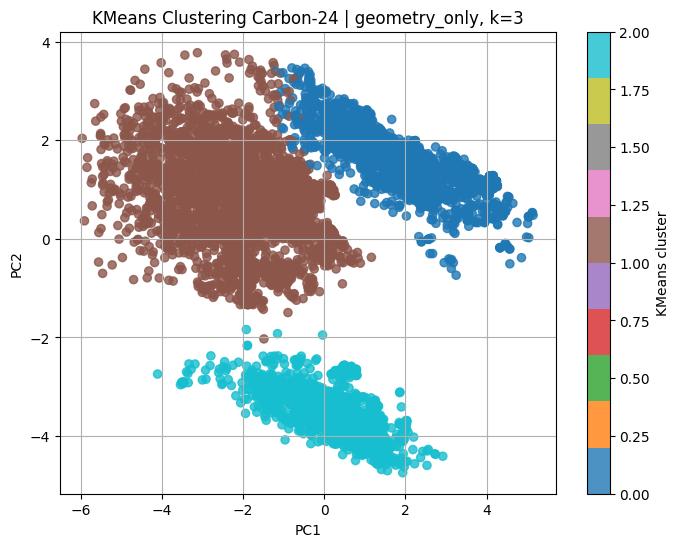

In [95]:
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    df_kmeans["PC1"],
    df_kmeans["PC2"],
    c=df_kmeans["cluster_kmeans"],
    cmap="tab10",
    s=35,
    alpha=0.8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clustering Carbon-24 | {best_feature_set}, k={best_k}")
plt.colorbar(sc, label="KMeans cluster")
plt.grid(True)

plt.savefig(f"{FIGURES_DIR}/kmeans_pca_clusters_best.png", dpi=200, bbox_inches="tight")
plt.show()

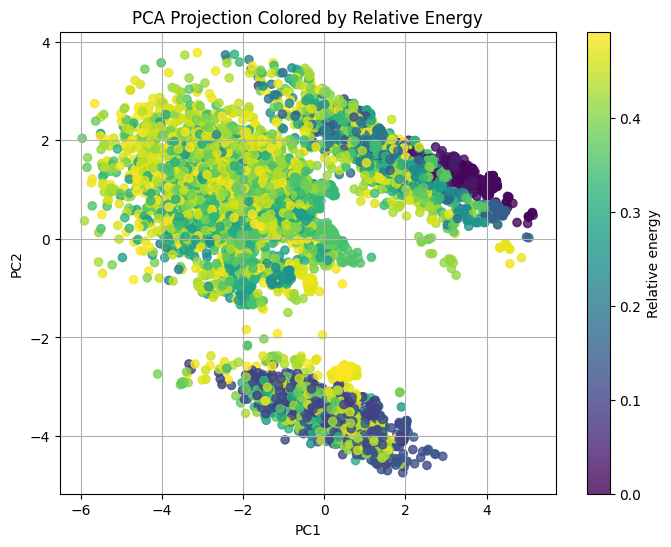

In [96]:
if "relative_energy" in df_kmeans.columns:
    plt.figure(figsize=(8, 6))
    
    sc = plt.scatter(
        df_kmeans["PC1"],
        df_kmeans["PC2"],
        c=df_kmeans["relative_energy"],
        cmap="viridis",
        s=35,
        alpha=0.8
    )
    
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Projection Colored by Relative Energy")
    plt.colorbar(sc, label="Relative energy")
    plt.grid(True)
    
    plt.savefig(f"{FIGURES_DIR}/kmeans_pca_by_relative_energy.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No relative_energy column found.")

**10. Energy boxplot theo cluster**

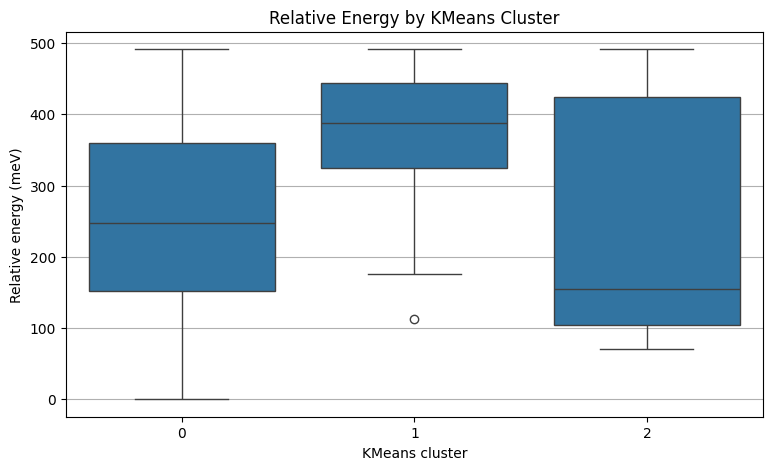

In [97]:
if "relative_energy" in df_kmeans.columns:
    df_kmeans["relative_energy_meV"] = df_kmeans["relative_energy"] * 1000
    
    plt.figure(figsize=(9, 5))
    
    sns.boxplot(
        data=df_kmeans,
        x="cluster_kmeans",
        y="relative_energy_meV"
    )
    
    plt.xlabel("KMeans cluster")
    plt.ylabel("Relative energy (meV)")
    plt.title("Relative Energy by KMeans Cluster")
    plt.grid(True, axis="y")
    
    plt.savefig(f"{FIGURES_DIR}/kmeans_energy_by_cluster.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No relative_energy column found.")

**11.  Density boxplot theo cluster**

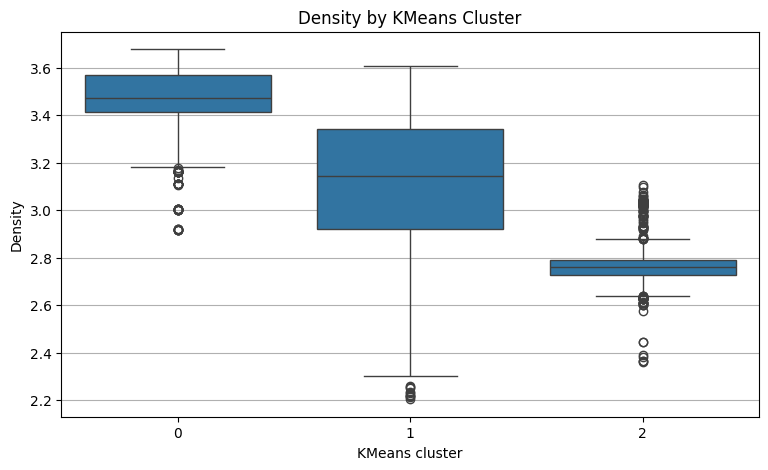

In [98]:
if "density" in df_kmeans.columns:
    plt.figure(figsize=(9, 5))
    
    sns.boxplot(
        data=df_kmeans,
        x="cluster_kmeans",
        y="density"
    )
    
    plt.xlabel("KMeans cluster")
    plt.ylabel("Density")
    plt.title("Density by KMeans Cluster")
    plt.grid(True, axis="y")
    
    plt.savefig(f"{FIGURES_DIR}/kmeans_density_by_cluster.png", dpi=200, bbox_inches="tight")
    plt.show()

**12. Volume per atom boxplot theo cluster**

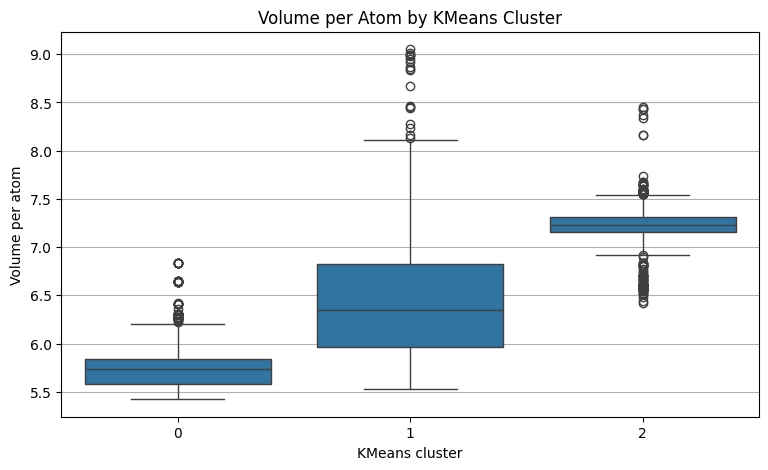

In [99]:
if "volume_per_atom" in df_kmeans.columns:
    plt.figure(figsize=(9, 5))
    
    sns.boxplot(
        data=df_kmeans,
        x="cluster_kmeans",
        y="volume_per_atom"
    )
    
    plt.xlabel("KMeans cluster")
    plt.ylabel("Volume per atom")
    plt.title("Volume per Atom by KMeans Cluster")
    plt.grid(True, axis="y")
    
    plt.savefig(f"{FIGURES_DIR}/kmeans_volume_per_atom_by_cluster.png", dpi=200, bbox_inches="tight")
    plt.show()

**13. Coordination boxplot theo cluster**

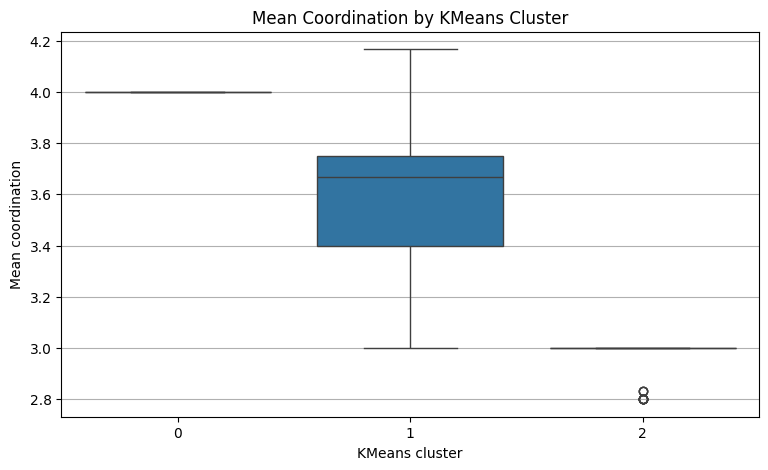

In [100]:
if "mean_coordination" in df_kmeans.columns:
    plt.figure(figsize=(9, 5))
    
    sns.boxplot(
        data=df_kmeans,
        x="cluster_kmeans",
        y="mean_coordination"
    )
    
    plt.xlabel("KMeans cluster")
    plt.ylabel("Mean coordination")
    plt.title("Mean Coordination by KMeans Cluster")
    plt.grid(True, axis="y")
    
    plt.savefig(f"{FIGURES_DIR}/kmeans_coordination_by_cluster.png", dpi=200, bbox_inches="tight")
    plt.show()

**14. Tạo cluster profile đầy đủ**

In [101]:
profile_cols = [
    "volume_per_atom",
    "density",
    "num_atoms",
    "a", "b", "c",
    "alpha", "beta", "gamma",
    "lattice_anisotropy",
    "angle_std",
    "mean_bond_length",
    "std_bond_length",
    "mean_coordination",
    "std_coordination",
    "relative_energy",
    "relative_energy_meV",
]

profile_cols = [c for c in profile_cols if c in df_kmeans.columns]

cluster_profile = df_kmeans.groupby("cluster_kmeans")[profile_cols].agg(
    ["count", "mean", "std", "min", "max"]
)

display(cluster_profile)

cluster_profile.to_csv(f"{TABLES_DIR}/kmeans_cluster_profile_full.csv")

volume_per_atom                                          \
                         count      mean       std       min       max   
cluster_kmeans                                                           
0                         3440  5.737082  0.211648  5.422302  6.839639   
1                         4470  6.427359  0.547182  5.528498  9.051862   
2                         2243  7.218300  0.186666  6.419073  8.448833   

               density                                         num_atoms  \
                 count      mean       std       min       max     count   
cluster_kmeans                                                             
0                 3440  3.481011  0.126011  2.915978  3.678186      3440   
1                 4470  3.124551  0.254276  2.203330  3.607533      4470   
2                 2243  2.764897  0.073166  2.360591  3.107028      2243   

                                                a                      \
                     mean       std min max count      mean       std   
cluster_kmeans                                                          
0                8.395349  2.721882   6  24  3440  2.758220  0.542802   
1               10.495302  4.165179   6  24  4470  2.680566  0.482654   
2                7.901917  2.473988   6  24  2243  3.016619  0.688351   

                                     b                                         \
                    min      max count      mean       std      min       max   
cluster_kmeans                                                                  
0               2.45052  5.69214  3440  4.041651  0.816228  2.46081   7.61141   
1               2.40084  6.50797  4470  4.590172  1.235163  2.40003  10.79477   
2               2.41754  6.26154  2243  4.075110  0.963503  2.41761   7.75640   

                   c                                        alpha             \
               count      mean       std      min       max count       mean   
cluster_kmeans                                                                 
0               3440  5.182208  1.261165  2.46291  12.31508  3440  88.517002   
1               4470  6.333741  1.679195  2.53903  14.92489  4470  89.591379   
2               2243  5.735573  1.563915  2.53075  17.31641  2243  88.669917   

                                                beta                        \
                      std       min        max count       mean        std   
cluster_kmeans                                                               
0               20.213506  33.67111  141.79385  3440  89.225396  16.212090   
1               19.763619  30.21128  145.74890  4470  89.837146  14.273797   
2               19.681550  34.28592  146.66272  2243  90.064085  16.757861   

                                    gamma                                  \
                     min        max count       mean        std       min   
cluster_kmeans                                                              
0               40.45505  140.73712  3440  88.745501  18.246127  39.24861   
1               40.07591  137.19527  4470  89.292521  15.726027  40.13941   
2               35.62898  140.09392  2243  89.454460  18.771721  33.27874   

                          lattice_anisotropy                                \
                      max              count      mean       std       min   
cluster_kmeans                                                               
0               136.97374               3440  2.021059  0.546738  1.000070   
1               151.66755               4470  2.527586  0.728571  1.000309   
2               146.66638               2243  2.133962  0.756745  1.001222   

                         angle_std                                            \
                     max     count       mean       std       min        max   
cluster_kmeans                                                                 
0               4.959639      3440  13.471892  6.873962  0.000265

**15. Tạo cluster summary**

In [102]:
summary_cols = [
    "volume_per_atom",
    "density",
    "num_atoms",
    "lattice_anisotropy",
    "mean_bond_length",
    "mean_coordination",
    "relative_energy_meV",
]

summary_cols = [c for c in summary_cols if c in df_kmeans.columns]

cluster_summary = df_kmeans.groupby("cluster_kmeans")[summary_cols].mean().reset_index()

cluster_counts = df_kmeans["cluster_kmeans"].value_counts().sort_index().reset_index()
cluster_counts.columns = ["cluster_kmeans", "n_samples"]

cluster_summary = cluster_counts.merge(cluster_summary, on="cluster_kmeans")

display(cluster_summary)

cluster_summary.to_csv(f"{TABLES_DIR}/kmeans_cluster_summary_report.csv", index=False)

,cluster_kmeans,n_samples,volume_per_atom,density,num_atoms,lattice_anisotropy,mean_bond_length,mean_coordination,relative_energy_meV
0,0,3440,5.737082,3.481011,8.395349,2.021059,1.527867,4.000000,243.724670
1,1,4470,6.427359,3.124551,10.495302,2.527586,1.488330,3.588667,380.060768
2,2,2243,7.218300,2.764897,7.901917,2.133962,1.406068,2.999064,256.009682


In [103]:
interpret_df = cluster_summary.copy()

if "relative_energy_meV" in interpret_df.columns:
    energy_mean = interpret_df["relative_energy_meV"].mean()
    interpret_df["energy_level"] = np.where(
        interpret_df["relative_energy_meV"] <= energy_mean,
        "lower-than-average energy",
        "higher-than-average energy"
    )

if "density" in interpret_df.columns:
    density_mean = interpret_df["density"].mean()
    interpret_df["density_level"] = np.where(
        interpret_df["density"] >= density_mean,
        "higher-density",
        "lower-density"
    )

if "volume_per_atom" in interpret_df.columns:
    vpa_mean = interpret_df["volume_per_atom"].mean()
    interpret_df["volume_level"] = np.where(
        interpret_df["volume_per_atom"] <= vpa_mean,
        "compact volume/atom",
        "large volume/atom"
    )

if "mean_coordination" in interpret_df.columns:
    coord_mean = interpret_df["mean_coordination"].mean()
    interpret_df["coordination_level"] = np.where(
        interpret_df["mean_coordination"] >= coord_mean,
        "higher coordination",
        "lower coordination"
    )

display(interpret_df)

interpret_df.to_csv(f"{TABLES_DIR}/kmeans_cluster_interpretation.csv", index=False)

,cluster_kmeans,n_samples,volume_per_atom,density,num_atoms,lattice_anisotropy,mean_bond_length,mean_coordination,relative_energy_meV,energy_level,density_level,volume_level,coordination_level
0,0,3440,5.737082,3.481011,8.395349,2.021059,1.527867,4.000000,243.724670,lower-than-average energy,higher-density,compact volume/atom,higher coordination
1,1,4470,6.427359,3.124551,10.495302,2.527586,1.488330,3.588667,380.060768,higher-than-average energy,higher-density,compact volume/atom,higher coordination
2,2,2243,7.218300,2.764897,7.901917,2.133962,1.406068,2.999064,256.009682,lower-than-average energy,lower-density,large volume/atom,lower coordination


**16. Chọn mẫu đại diện**

In [104]:
centers = kmeans_final.cluster_centers_
labels = df_kmeans["cluster_kmeans"].values

representative_rows = []

for cluster_id in sorted(df_kmeans["cluster_kmeans"].unique()):
    mask = labels == cluster_id
    
    X_cluster = X_best[mask]
    df_cluster = df_kmeans.loc[mask].copy()
    
    center = centers[cluster_id]
    distances = np.linalg.norm(X_cluster - center, axis=1)
    
    df_cluster["distance_to_cluster_center"] = distances
    
    top_rep = df_cluster.sort_values("distance_to_cluster_center").head(5)
    representative_rows.append(top_rep)

representatives_df = pd.concat(representative_rows, ignore_index=True)

display(representatives_df.head(30))

representatives_df.to_csv(f"{RESULTS_DIR}/kmeans_representative_samples.csv", index=False)

,formula,elements,num_atoms,a,b,c,alpha,beta,gamma,volume,volume_per_atom,density,b_over_a,c_over_a,angle_deviation,space_group_number,space_group_symbol,crystal_system,mean_bond_length,std_bond_length,min_bond_length,max_bond_length,mean_coordination,std_coordination,min_coordination,max_coordination,row_index,split,source_file,material_id,energy,relative_energy,relative_energy_meV,lattice_min,lattice_max,lattice_anisotropy,angle_mean,angle_std,density_x_volume_per_atom,cluster_kmeans,PC1,PC2,distance_to_cluster_center
0,C,C,8,2.48189,3.66611,5.57014,70.79603,102.90088,89.99624,46.504657,5.813082,3.430923,1.477144,2.244314,32.10861,74,Imma,orthorhombic,1.525912,0.028861,1.493731,1.582403,4.000000,0.000000,4.0,4.0,6692,validation,huggingface,C-34631-1494-22,-154.242554,0.314431,314.431250,2.48189,5.57014,2.244314,87.897717,16.154974,19.944237,0,2.138813,1.503649,1.645659
1,C,C,8,2.48254,3.66615,5.57140,70.83190,102.89190,90.01760,46.541994,5.817749,3.428171,1.476774,2.244234,32.07760,74,Imma,orthorhombic,1.526165,0.029453,1.493718,1.577988,4.000000,0.000000,4.0,4.0,2292,train,huggingface,C-177268-8621-15,-154.247101,0.309884,309.883750,2.48254,5.57140,2.244234,87.913800,16.133207,19.944237,0,2.135350,1.484751,1.647055
2,C,C,8,2.48183,3.66734,5.57139,70.76568,102.88380,89.99238,46.523783,5.815473,3.429512,1.477676,2.244872,32.12574,74,Imma,orthorhombic,1.525969,0.029123,1.493057,1.576678,4.000000,0.000000,4.0,4.0,9212,test,huggingface,C-56512-1663-8,-154.244689,0.312296,312.296250,2.48183,5.57139,2.244872,87.880620,16.162860,19.944237,0,2.137318,1.472803,1.648648
3,C,C,8,2.48175,3.66568,5.57340,109.22239,77.14325,90.00684,46.528268,5.816034,3.429182,1.477054,2.245754,32.08598,74,Imma,orthorhombic,1.526138,0.028831,1.492361,1.577544,4.000000,0.000000,4.0,4.0,8585,test,huggingface,C-148244-5888-7,-154.244291,0.312694,312.693750,2.48175,5.57340,2.245754,92.124160,16.144042,19.944237,0,2.119767,1.491440,1.702062
4,C,C,8,2.48171,3.66290,5.57521,109.24690,77.09934,89.97661,46.488636,5.811079,3.432105,1.475958,2.246520,32.17095,74,Imma,orthorhombic,1.525877,0.028827,1.491451,1.581182,4.000000,0.000000,4.0,4.0,8637,test,huggingface,C-75995-2520-48,-154.242056,0.314929,314.928750,2.48171,5.57521,2.246520,92.107617,16.179379,19.944237,0,2.111851,1.508145,1.702391
5,C,C,10,2.46311,4.44460,6.09204,104.79722,83.10291,84.13512,63.398256,6.339826,3.145865,1.804467,2.473312,27.55919,2,P-1,triclinic,1.488683,0.042689,1.358940,1.554571,3.800000,0.400000,3.0,4.0,3591,train,huggingface,C-172947-5402-6,-154.125671,0.431314,431.314000,2.46311,6.09204,2.473312,90.678417,12.238130,19.944237,1,-1.570049,0.364630,1.510635
6,C,C,10,2.51100,4.40458,5.54852,77.33340,95.00488,95.99271,59.414316,5.941432,3.356807,1.754114,2.209685,23.66419,2,P-1,triclinic,1.500644,0.061421,1.363623,1.592367,3.600000,0.489898,3.0,4.0,7054,validation,huggingface,C-141045-9787-14,-154.067835,0.489150,489.150000,2.51100,5.54852,2.209685,89.443663,10.499420,19.944237,1,-1.573057,1.083015,1.609231
7,C,C,12,2.53677,4.79076,6.40758,70.83765,90.26995,90.03532,73.556135,6.129678,3.253717,1.888528,2.525881,19.46762,10,P2/m,monoclinic,1.499835,0.062439,1.370945,1.592453,3.666667,0.471405,3.0,4.0,7687,validation,huggingface,C-34629-5612-24,-154.272062,0.284923,284.923333,2.53677,6.40758,2.525881,83.714307,11.152129,19.944237,1,-2.137381,1.163028,1.636438
8,C,C,12,2.53627,4.78938,6.41162,109.22825,90.94689,89.91093,73.527542,6.127295,3.254982,1.888356,2.527972,20.26421,10,P2/m,monoclinic,1.499927,0.063268,1.367848,1.595640,3.666667,0.471405,3.0,4.0,7514,validation,huggingface,C-106859-2905-32,-154.271325,0.285660,285.660000,2.53627,6.41162,2.527972,96.695357,10.866157,19.944237,1,-2.216378,1.161937,1.679935
9,C,C,10,2.51799,4.75297,5.42017,89.07206,103.44795,74.67748,60.638185,6.063819,3.289056,1.887605,2.152578,29.69841,12,C2/m,monoclinic,1.495926,0.059738,1.363230,1.588459,3.600000,0.489898,3.0,4.0,10119,test,huggingface,C-130522-136-22,-154.187591,0.369394,369.394000,2.51799,5.42017,2.

**17. Lưu bảng kết quả KMeans**

In [106]:
report_cols = [
    "method",
    "feature_set",
    "k",
    "n_samples",
    "n_features",
    "inertia",
    "silhouette",
    "davies_bouldin",
    "calinski_harabasz",
]

report_cols = [c for c in report_cols if c in kmeans_results_df.columns]

kmeans_report_table = kmeans_results_df[report_cols].copy()

display(kmeans_report_table)

kmeans_report_table.to_csv(f"{RESULTS_DIR}/kmeans_report_table.csv", index=False)

,method,feature_set,k,n_samples,n_features,inertia,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,geometry_only,2,10153,21,174988.916933,0.182831,1.909765,2217.355670
1,KMeans,geometry_only,3,10153,21,139794.523536,0.243012,1.606407,2665.331650
2,KMeans,geometry_only,4,10153,21,128443.801391,0.204406,1.794290,2232.686213
3,KMeans,geometry_only,5,10153,21,120784.152670,0.195017,1.828536,1941.414685
4,KMeans,geometry_only,6,10153,21,114829.693840,0.191621,1.722772,1738.742146
5,KMeans,geometry_only,7,10153,21,109535.745591,0.173654,1.865861,1600.559186
6,KMeans,geometry_only,8,10153,21,104484.140311,0.159710,1.977445,1508.163656
7,KMeans,geometry_only,9,10153,21,100575.995501,0.162603,1.869390,1420.058257
8,KMeans,geometry_only,10,10153,21,97145.858150,0.159435,1.846420,1346.508811
9,KMeans,geometry_energy,2,10153,22,184077.635447,0.179813,1.936799,2166.565143


In [107]:
print("Results files:")
!find /kaggle/working/carbon24_kmeans_baseline -type f | sort

Results files:
/kaggle/working/carbon24_kmeans_baseline/data/carbon24_features_engineered.csv
/kaggle/working/carbon24_kmeans_baseline/data/carbon24_features_loaded.csv
/kaggle/working/carbon24_kmeans_baseline/figures/corr_heatmap_after_geometry_energy.png
/kaggle/working/carbon24_kmeans_baseline/figures/corr_heatmap_after_geometry_only.png
/kaggle/working/carbon24_kmeans_baseline/figures/corr_heatmap_before_geometry_energy.png
/kaggle/working/carbon24_kmeans_baseline/figures/corr_heatmap_before_geometry_only.png
/kaggle/working/carbon24_kmeans_baseline/figures/distribution_geometry_energy_angle_std.png
/kaggle/working/carbon24_kmeans_baseline/figures/distribution_geometry_energy_density.png
/kaggle/working/carbon24_kmeans_baseline/figures/distribution_geometry_energy_lattice_anisotropy.png
/kaggle/working/carbon24_kmeans_baseline/figures/distribution_geometry_energy_mean_bond_length.png
/kaggle/working/carbon24_kmeans_baseline/figures/distribution_geometry_energy_mean_coordination.png

In [108]:
%cd /kaggle/working

!zip -r carbon24_kmeans_baseline_results.zip carbon24_kmeans_baseline

!ls -lh carbon24_kmeans_baseline_results.zip

/kaggle/working
updating: carbon24_kmeans_baseline/ (stored 0%)
updating: carbon24_kmeans_baseline/results/ (stored 0%)
updating: carbon24_kmeans_baseline/results/kmeans_best_per_feature_set.csv (deflated 32%)
updating: carbon24_kmeans_baseline/results/kmeans_results_all.csv (deflated 55%)
updating: carbon24_kmeans_baseline/results/kmeans_cluster_assignments_best.csv (deflated 63%)
updating: carbon24_kmeans_baseline/results/kmeans_report_table.csv (deflated 55%)
updating: carbon24_kmeans_baseline/tables/ (stored 0%)
updating: carbon24_kmeans_baseline/tables/kmeans_cluster_profile_best.csv (deflated 60%)
updating: carbon24_kmeans_baseline/tables/missing_report.csv (deflated 63%)
updating: carbon24_kmeans_baseline/tables/kmeans_cluster_summary_best.csv (deflated 37%)
updating: carbon24_kmeans_baseline/figures/ (stored 0%)
updating: carbon24_kmeans_baseline/figures/kmeans_energy_by_cluster.png (deflated 23%)
updating: carbon24_kmeans_baseline/figures/kmeans_silhouette_by_k.png (deflated 9

In [110]:
final_kmeans_summary = pd.DataFrame([{
    "method": "KMeans",
    "best_feature_set": best_feature_set,
    "best_k": best_k,
    "n_samples": int(X_best.shape[0]),
    "n_features": int(X_best.shape[1]),
    "inertia": float(best_row["inertia"]),
    "silhouette": float(best_row["silhouette"]),
    "davies_bouldin": float(best_row["davies_bouldin"]),
    "calinski_harabasz": float(best_row["calinski_harabasz"]),
}])

display(final_kmeans_summary)

final_kmeans_summary.to_csv(
    f"{RESULTS_DIR}/final_kmeans_summary.csv",
    index=False
)

,method,best_feature_set,best_k,n_samples,n_features,inertia,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,geometry_only,3,10153,21,139794.523536,0.243012,1.606407,2665.33165


***Kiểm tra cụm ổn định năng lượng nhất***

In [111]:
if "relative_energy_meV" in df_kmeans.columns:
    energy_cluster_summary = (
        df_kmeans
        .groupby("cluster_kmeans")["relative_energy_meV"]
        .agg(["count", "mean", "std", "min", "median", "max"])
        .reset_index()
        .sort_values("mean")
    )
    
    display(energy_cluster_summary)
    
    energy_cluster_summary.to_csv(
        f"{TABLES_DIR}/kmeans_energy_cluster_summary.csv",
        index=False
    )
    
    most_stable_cluster = int(energy_cluster_summary.iloc[0]["cluster_kmeans"])
    least_stable_cluster = int(energy_cluster_summary.iloc[-1]["cluster_kmeans"])
    
    print("Most stable cluster by mean relative energy:", most_stable_cluster)
    print("Least stable cluster by mean relative energy:", least_stable_cluster)
else:
    print("No relative_energy_meV column found.")

,cluster_kmeans,count,mean,std,min,median,max
0,0,3440,243.724670,139.747183,0.00000,246.912000,491.201000
2,2,2243,256.009682,157.264195,70.14500,155.106250,491.283000
1,1,4470,380.060768,71.865604,112.79875,387.839167,491.383125


Most stable cluster by mean relative energy: 0
Least stable cluster by mean relative energy: 1


In [112]:
if "density" in df_kmeans.columns:
    density_cluster_summary = (
        df_kmeans
        .groupby("cluster_kmeans")["density"]
        .agg(["count", "mean", "std", "min", "median", "max"])
        .reset_index()
        .sort_values("mean", ascending=False)
    )
    
    display(density_cluster_summary)
    
    density_cluster_summary.to_csv(
        f"{TABLES_DIR}/kmeans_density_cluster_summary.csv",
        index=False
    )
    
    highest_density_cluster = int(density_cluster_summary.iloc[0]["cluster_kmeans"])
    lowest_density_cluster = int(density_cluster_summary.iloc[-1]["cluster_kmeans"])
    
    print("Highest density cluster:", highest_density_cluster)
    print("Lowest density cluster:", lowest_density_cluster)
else:
    print("No density column found.")

,cluster_kmeans,count,mean,std,min,median,max
0,0,3440,3.481011,0.126011,2.915978,3.474283,3.678186
1,1,4470,3.124551,0.254276,2.203330,3.141954,3.607533
2,2,2243,2.764897,0.073166,2.360591,2.759394,3.107028


Highest density cluster: 0
Lowest density cluster: 2


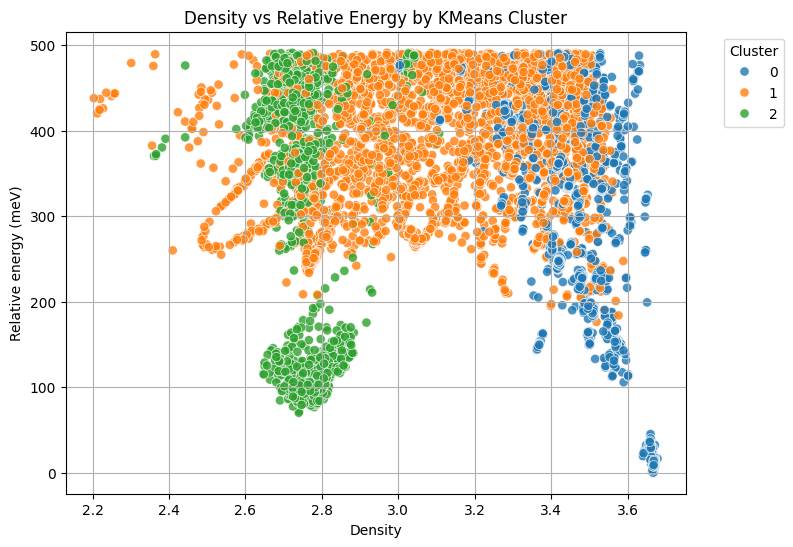

In [113]:
if "density" in df_kmeans.columns and "relative_energy_meV" in df_kmeans.columns:
    plt.figure(figsize=(8, 6))
    
    sns.scatterplot(
        data=df_kmeans,
        x="density",
        y="relative_energy_meV",
        hue="cluster_kmeans",
        palette="tab10",
        s=45,
        alpha=0.8
    )
    
    plt.xlabel("Density")
    plt.ylabel("Relative energy (meV)")
    plt.title("Density vs Relative Energy by KMeans Cluster")
    plt.grid(True)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.savefig(
        f"{FIGURES_DIR}/kmeans_density_vs_energy.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    print("Need density and relative_energy_meV columns.")

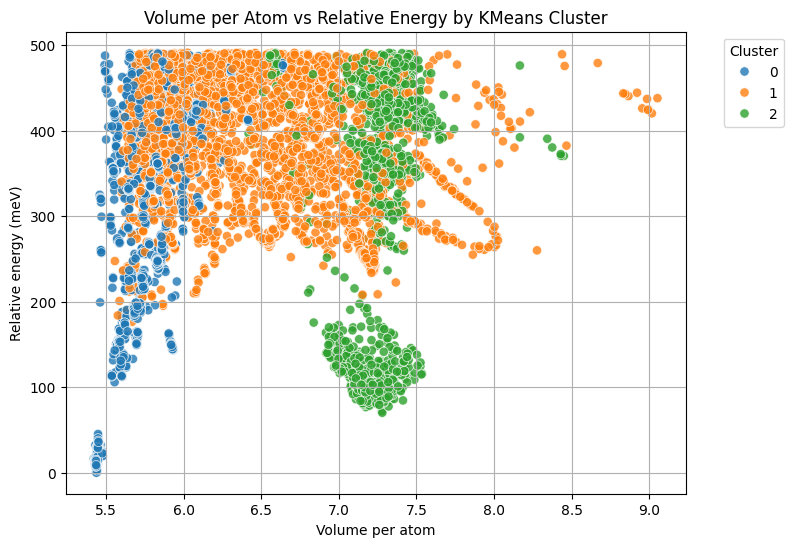

In [114]:
if "volume_per_atom" in df_kmeans.columns and "relative_energy_meV" in df_kmeans.columns:
    plt.figure(figsize=(8, 6))
    
    sns.scatterplot(
        data=df_kmeans,
        x="volume_per_atom",
        y="relative_energy_meV",
        hue="cluster_kmeans",
        palette="tab10",
        s=45,
        alpha=0.8
    )
    
    plt.xlabel("Volume per atom")
    plt.ylabel("Relative energy (meV)")
    plt.title("Volume per Atom vs Relative Energy by KMeans Cluster")
    plt.grid(True)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.savefig(
        f"{FIGURES_DIR}/kmeans_volume_per_atom_vs_energy.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    print("Need volume_per_atom and relative_energy_meV columns.")

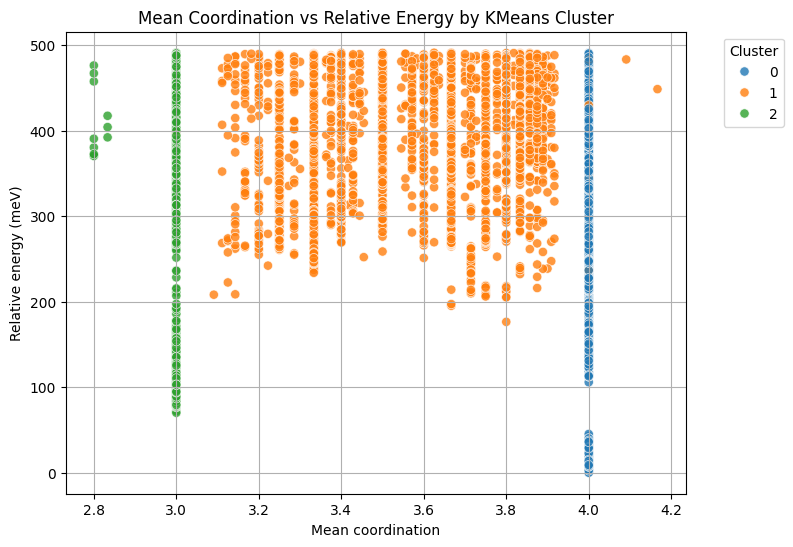

In [115]:
if "mean_coordination" in df_kmeans.columns and "relative_energy_meV" in df_kmeans.columns:
    plt.figure(figsize=(8, 6))
    
    sns.scatterplot(
        data=df_kmeans,
        x="mean_coordination",
        y="relative_energy_meV",
        hue="cluster_kmeans",
        palette="tab10",
        s=45,
        alpha=0.8
    )
    
    plt.xlabel("Mean coordination")
    plt.ylabel("Relative energy (meV)")
    plt.title("Mean Coordination vs Relative Energy by KMeans Cluster")
    plt.grid(True)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.savefig(
        f"{FIGURES_DIR}/kmeans_coordination_vs_energy.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    print("Need mean_coordination and relative_energy_meV columns.")

crystal_system,cubic,hexagonal,monoclinic,orthorhombic,tetragonal,triclinic,trigonal
cluster_kmeans,,,,,,,
0,0.106686,0.068314,0.423837,0.212209,0.013953,0.126453,0.048547
1,0.000000,0.000000,0.547204,0.182774,0.001119,0.268680,0.000224
2,0.000000,0.004904,0.387873,0.060187,0.000000,0.430227,0.116808


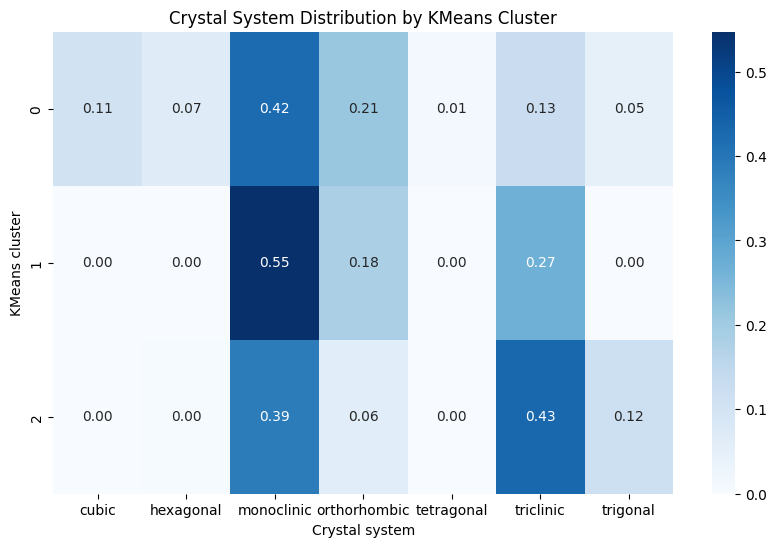

In [116]:
if "crystal_system" in df_kmeans.columns:
    crystal_cluster_ct = pd.crosstab(
        df_kmeans["cluster_kmeans"],
        df_kmeans["crystal_system"],
        normalize="index"
    )
    
    display(crystal_cluster_ct)
    
    crystal_cluster_ct.to_csv(
        f"{TABLES_DIR}/kmeans_crystal_system_ratio_by_cluster.csv"
    )
    
    plt.figure(figsize=(10, 6))
    
    sns.heatmap(
        crystal_cluster_ct,
        cmap="Blues",
        annot=True,
        fmt=".2f"
    )
    
    plt.xlabel("Crystal system")
    plt.ylabel("KMeans cluster")
    plt.title("Crystal System Distribution by KMeans Cluster")
    
    plt.savefig(
        f"{FIGURES_DIR}/kmeans_crystal_system_heatmap.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    print("No crystal_system column found.")

In [117]:
cluster_description_rows = []

for _, row in interpret_df.iterrows():
    cluster_id = int(row["cluster_kmeans"])
    
    desc_parts = []
    
    if "density_level" in row:
        desc_parts.append(str(row["density_level"]))
    
    if "volume_level" in row:
        desc_parts.append(str(row["volume_level"]))
    
    if "coordination_level" in row:
        desc_parts.append(str(row["coordination_level"]))
    
    if "energy_level" in row:
        desc_parts.append(str(row["energy_level"]))
    
    description = ", ".join(desc_parts)
    
    cluster_description_rows.append({
        "cluster_kmeans": cluster_id,
        "n_samples": int(row["n_samples"]),
        "description_en": description,
        "description_vi": (
            "Cụm có " + description
            if len(description) > 0
            else "Cụm cần phân tích thêm"
        )
    })

cluster_description_df = pd.DataFrame(cluster_description_rows)

display(cluster_description_df)

cluster_description_df.to_csv(
    f"{TABLES_DIR}/kmeans_cluster_description_draft.csv",
    index=False
)

,cluster_kmeans,n_samples,description_en,description_vi
0,0,3440,"higher-density, compact volume/atom, higher co...","Cụm có higher-density, compact volume/atom, hi..."
1,1,4470,"higher-density, compact volume/atom, higher co...","Cụm có higher-density, compact volume/atom, hi..."
2,2,2243,"lower-density, large volume/atom, lower coordi...","Cụm có lower-density, large volume/atom, lower..."


In [118]:
cluster_name_rows = []

for _, row in interpret_df.iterrows():
    cluster_id = int(row["cluster_kmeans"])
    
    name_parts = []
    
    if "density" in row and "volume_per_atom" in row:
        if row["density"] >= interpret_df["density"].mean():
            name_parts.append("dense")
        else:
            name_parts.append("open")
    
    if "relative_energy_meV" in row:
        if row["relative_energy_meV"] <= interpret_df["relative_energy_meV"].mean():
            name_parts.append("stable")
        else:
            name_parts.append("metastable")
    
    if "mean_coordination" in row:
        if row["mean_coordination"] >= interpret_df["mean_coordination"].mean():
            name_parts.append("high-coordination")
        else:
            name_parts.append("low-coordination")
    
    cluster_name = "-".join(name_parts) if len(name_parts) > 0 else f"cluster-{cluster_id}"
    
    cluster_name_rows.append({
        "cluster_kmeans": cluster_id,
        "suggested_cluster_name": cluster_name
    })

cluster_names_df = pd.DataFrame(cluster_name_rows)

display(cluster_names_df)

cluster_names_df.to_csv(
    f"{TABLES_DIR}/kmeans_suggested_cluster_names.csv",
    index=False
)

,cluster_kmeans,suggested_cluster_name
0,0,dense-stable-high-coordination
1,1,dense-metastable-high-coordination
2,2,open-stable-low-coordination


In [119]:
cluster_summary_named = cluster_summary.merge(
    cluster_names_df,
    on="cluster_kmeans",
    how="left"
)

display(cluster_summary_named)

cluster_summary_named.to_csv(
    f"{TABLES_DIR}/kmeans_cluster_summary_named.csv",
    index=False
)

,cluster_kmeans,n_samples,volume_per_atom,density,num_atoms,lattice_anisotropy,mean_bond_length,mean_coordination,relative_energy_meV,suggested_cluster_name
0,0,3440,5.737082,3.481011,8.395349,2.021059,1.527867,4.000000,243.724670,dense-stable-high-coordination
1,1,4470,6.427359,3.124551,10.495302,2.527586,1.488330,3.588667,380.060768,dense-metastable-high-coordination
2,2,2243,7.218300,2.764897,7.901917,2.133962,1.406068,2.999064,256.009682,open-stable-low-coordination


In [120]:
md_path = f"{REPORT_DIR}/kmeans_baseline_notes.md"

with open(md_path, "w", encoding="utf-8") as f:
    f.write("# KMeans Baseline Notes\n\n")
    
    f.write("## Best configuration\n\n")
    f.write(f"- Best feature set: `{best_feature_set}`\n")
    f.write(f"- Best k: `{best_k}`\n")
    f.write(f"- Silhouette score: `{best_row['silhouette']:.4f}`\n")
    f.write(f"- Davies-Bouldin index: `{best_row['davies_bouldin']:.4f}`\n")
    f.write(f"- Calinski-Harabasz score: `{best_row['calinski_harabasz']:.4f}`\n\n")
    
    f.write("## Cluster size\n\n")
    cluster_counts_md = df_kmeans["cluster_kmeans"].value_counts().sort_index()
    for cluster_id, count in cluster_counts_md.items():
        f.write(f"- Cluster {cluster_id}: {count} samples\n")
    
    f.write("\n## Energy interpretation\n\n")
    if "relative_energy_meV" in df_kmeans.columns:
        f.write(
            f"- Most stable cluster by mean relative energy: "
            f"`{most_stable_cluster}`\n"
        )
        f.write(
            f"- Least stable cluster by mean relative energy: "
            f"`{least_stable_cluster}`\n"
        )
    
    f.write("\n## Suggested interpretation\n\n")
    for _, row in cluster_summary_named.iterrows():
        f.write(
            f"- Cluster {int(row['cluster_kmeans'])} "
            f"({row.get('suggested_cluster_name', 'unnamed')}): "
            f"{int(row['n_samples'])} samples"
        )
        
        if "relative_energy_meV" in row:
            f.write(
                f", mean relative energy = {row['relative_energy_meV']:.2f} meV"
            )
        
        if "density" in row:
            f.write(
                f", mean density = {row['density']:.3f}"
            )
        
        if "volume_per_atom" in row:
            f.write(
                f", mean volume/atom = {row['volume_per_atom']:.3f}"
            )
        
        f.write(".\n")

print("Saved:", md_path)

Saved: /kaggle/working/carbon24_kmeans_baseline/reports/kmeans_baseline_notes.md


In [121]:
!find /kaggle/working/carbon24_kmeans_baseline -type f | sort

/kaggle/working/carbon24_kmeans_baseline/data/carbon24_features_engineered.csv
/kaggle/working/carbon24_kmeans_baseline/data/carbon24_features_loaded.csv
/kaggle/working/carbon24_kmeans_baseline/figures/corr_heatmap_after_geometry_energy.png
/kaggle/working/carbon24_kmeans_baseline/figures/corr_heatmap_after_geometry_only.png
/kaggle/working/carbon24_kmeans_baseline/figures/corr_heatmap_before_geometry_energy.png
/kaggle/working/carbon24_kmeans_baseline/figures/corr_heatmap_before_geometry_only.png
/kaggle/working/carbon24_kmeans_baseline/figures/distribution_geometry_energy_angle_std.png
/kaggle/working/carbon24_kmeans_baseline/figures/distribution_geometry_energy_density.png
/kaggle/working/carbon24_kmeans_baseline/figures/distribution_geometry_energy_lattice_anisotropy.png
/kaggle/working/carbon24_kmeans_baseline/figures/distribution_geometry_energy_mean_bond_length.png
/kaggle/working/carbon24_kmeans_baseline/figures/distribution_geometry_energy_mean_coordination.png
/kaggle/workin

In [122]:
%cd /kaggle/working

!zip -r carbon24_kmeans_baseline_results_final.zip carbon24_kmeans_baseline

!ls -lh carbon24_kmeans_baseline_results_final.zip

/kaggle/working
  adding: carbon24_kmeans_baseline/ (stored 0%)
  adding: carbon24_kmeans_baseline/preprocessing/ (stored 0%)
  adding: carbon24_kmeans_baseline/preprocessing/X_scaled_geometry_energy.csv (deflated 60%)
  adding: carbon24_kmeans_baseline/preprocessing/X_scaled_geometry_only.csv (deflated 61%)
  adding: carbon24_kmeans_baseline/results/ (stored 0%)
  adding: carbon24_kmeans_baseline/results/kmeans_best_by_silhouette.csv (deflated 52%)
  adding: carbon24_kmeans_baseline/results/kmeans_best_per_feature_set.csv (deflated 32%)
  adding: carbon24_kmeans_baseline/results/kmeans_best_config.json (deflated 53%)
  adding: carbon24_kmeans_baseline/results/kmeans_results_all.csv (deflated 55%)
  adding: carbon24_kmeans_baseline/results/kmeans_cluster_assignments_best.csv (deflated 63%)
  adding: carbon24_kmeans_baseline/results/final_kmeans_summary.csv (deflated 23%)
  adding: carbon24_kmeans_baseline/results/kmeans_report_table.csv (deflated 55%)
  adding: carbon24_kmeans_baseline